In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 설정
plt.style.use('seaborn-v0_8')
plt.rc('font', family='Malgun Gothic')       # 한글 폰트 설정
plt.rc('axes', unicode_minus=False)          # 마이너스 기호 깨짐 방지
sns.set_palette("husl")
%matplotlib inline

# 와인 품질 데이터 전처리

이 노트북은 `wine_data_homework.csv` 데이터를 전처리하는 과정을 보여줍니다.

전처리 단계:
1. 데이터 로드 및 기본 정보 확인
2. 결측치 확인 및 처리
3. 이상치 탐지 및 제거 (IQR 방법)
4. 상관관계 분석 및 다중공선성 피처 제거
5. 전처리된 데이터 저장


## 1. 데이터 로드 및 기본 정보 확인


In [2]:
# 데이터 로드
csv_path = 'wine_data_homework.csv'
df = pd.read_csv(csv_path)

print(f"원본 데이터 크기: {df.shape}")
print(f"\n컬럼 목록:")
print(df.columns.tolist())
print(f"\n데이터 타입:")
print(df.dtypes)


원본 데이터 크기: (4001, 13)

컬럼 목록:
['Unnamed: 0', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

데이터 타입:
Unnamed: 0                int64
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [3]:
# 불필요한 인덱스 컬럼 제거 (있는 경우)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("인덱스 컬럼 제거 완료")

# 기본 통계 정보
print("\n=== 기본 통계 정보 ===")
df.describe()


인덱스 컬럼 제거 완료

=== 기본 통계 정보 ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000,4001.000000
mean,6.957073,0.275809,0.341135,6.363922,0.045632,35.571357,140.483504,0.994188,3.191922,0.489360,10.461235,5.879780
std,0.844565,0.100173,0.122555,5.091003,0.021958,16.909183,43.260052,0.002992,0.152905,0.114944,1.215411,0.909832
min,4.200000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987130,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.210000,0.270000,1.700000,0.036000,24.000000,109.000000,0.991880,3.090000,0.410000,9.400000,5.000000
50%,6.900000,0.260000,0.320000,5.200000,0.043000,34.000000,137.000000,0.993900,3.180000,0.470000,10.300000,6.000000
75%,7.400000,0.320000,0.400000,9.800000,0.050000,46.000000,170.000000,0.996250,3.290000,0.550000,11.300000,6.000000
max,14.200000,1.005000,1.660000,65.800000,0.346000,146.500000,366.500000,1.038980,3.820000,1.060000,14.200000,9.000000



=== Quality 분포 ===
quality
3      19
4     142
5    1214
6    1718
7     747
8     156
9       5
Name: count, dtype: int64

Quality 범위: 3 ~ 9


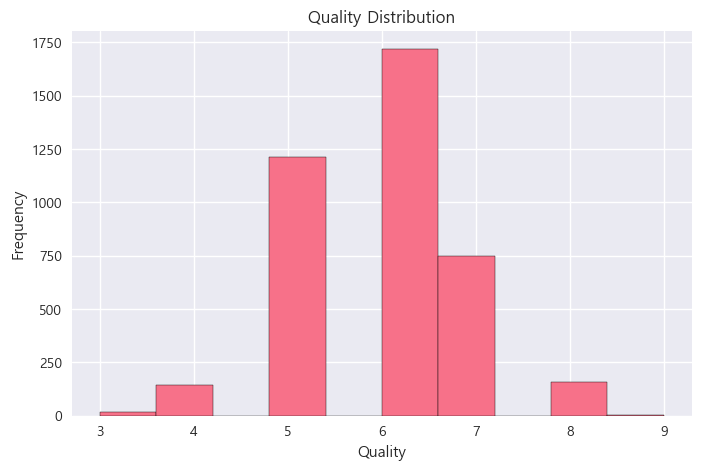

In [4]:
# 타겟 변수(quality) 분포 확인
print("\n=== Quality 분포 ===")
print(df['quality'].value_counts().sort_index())
print(f"\nQuality 범위: {df['quality'].min()} ~ {df['quality'].max()}")

plt.figure(figsize=(8, 5))
df['quality'].hist(bins=10, edgecolor='black')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.title('Quality Distribution')
plt.show()


## 2. 결측치 확인 및 처리


In [5]:
# 결측치 확인
print("=== 결측치 개수 ===")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() > 0:
    print(f"\n총 결측치 개수: {missing_values.sum()}")
    # 결측치 시각화
    plt.figure(figsize=(10, 6))
    missing_values[missing_values > 0].plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("\n결측치가 없습니다.")


=== 결측치 개수 ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

결측치가 없습니다.


In [6]:
# 결측치 처리 (평균값으로 대체)
if missing_values.sum() > 0:
    df = df.fillna(df.mean(numeric_only=True))
    print("결측치를 평균값으로 대체했습니다.")
    print(f"처리 후 결측치 개수: {df.isnull().sum().sum()}")


## 3. 이상치 탐지 및 제거 (IQR 방법)


In [7]:
# IQR 기반 이상치 탐지
# 각 피처에 대해 IQR(Inter-Quartile Range) 계산
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# 이상치 범위: Q1 - 1.5*IQR ~ Q3 + 1.5*IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("=== 이상치 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===")
outlier_info = pd.DataFrame({
    'Lower Bound': lower_bound,
    'Upper Bound': upper_bound
})
print(outlier_info)


=== 이상치 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar         -10.450000    21.950000
chlorides                0.015000     0.071000
free sulfur dioxide     -9.000000    79.000000
total sulfur dioxide    17.500000   261.500000
density                  0.985325     1.002805
pH                       2.790000     3.590000
sulphates                0.200000     0.760000
alcohol                  6.550000    14.150000
quality                  3.500000     7.500000


In [8]:
# 이상치가 있는 행 찾기
# quality 컬럼은 제외 (타겟 변수이므로)
feature_cols = [col for col in df.columns if col != 'quality']

outlier_mask = ~((df[feature_cols] < lower_bound[feature_cols]) | 
                 (df[feature_cols] > upper_bound[feature_cols])).any(axis=1)

n_outliers = (~outlier_mask).sum()
print(f"이상치로 판단된 행 수: {n_outliers}개 ({n_outliers/len(df)*100:.2f}%)")

# 이상치 제거
df_clean = df[outlier_mask].copy()
print(f"\n이상치 제거 전 데이터 크기: {df.shape}")
print(f"이상치 제거 후 데이터 크기: {df_clean.shape}")
print(f"제거된 행 수: {df.shape[0] - df_clean.shape[0]}개")


이상치로 판단된 행 수: 709개 (17.72%)

이상치 제거 전 데이터 크기: (4001, 12)
이상치 제거 후 데이터 크기: (3292, 12)
제거된 행 수: 709개


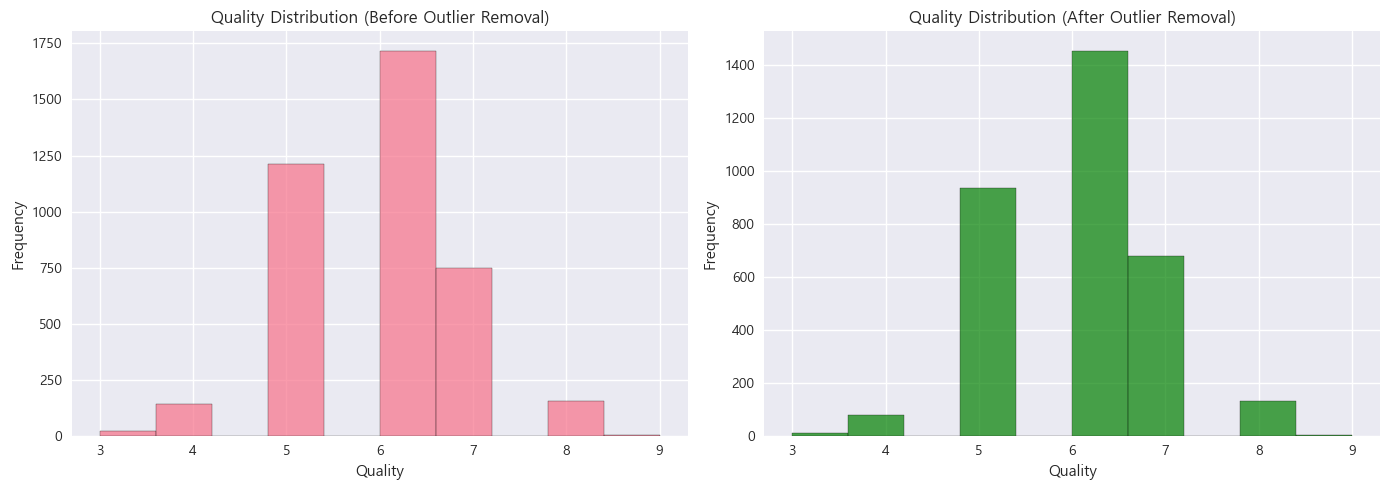

In [9]:
# 이상치 제거 전후 Quality 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['quality'], bins=10, edgecolor='black', alpha=0.7)
axes[0].set_title('Quality Distribution (Before Outlier Removal)')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_clean['quality'], bins=10, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Quality Distribution (After Outlier Removal)')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## 4. 상관관계 분석 및 다중공선성 피처 제거


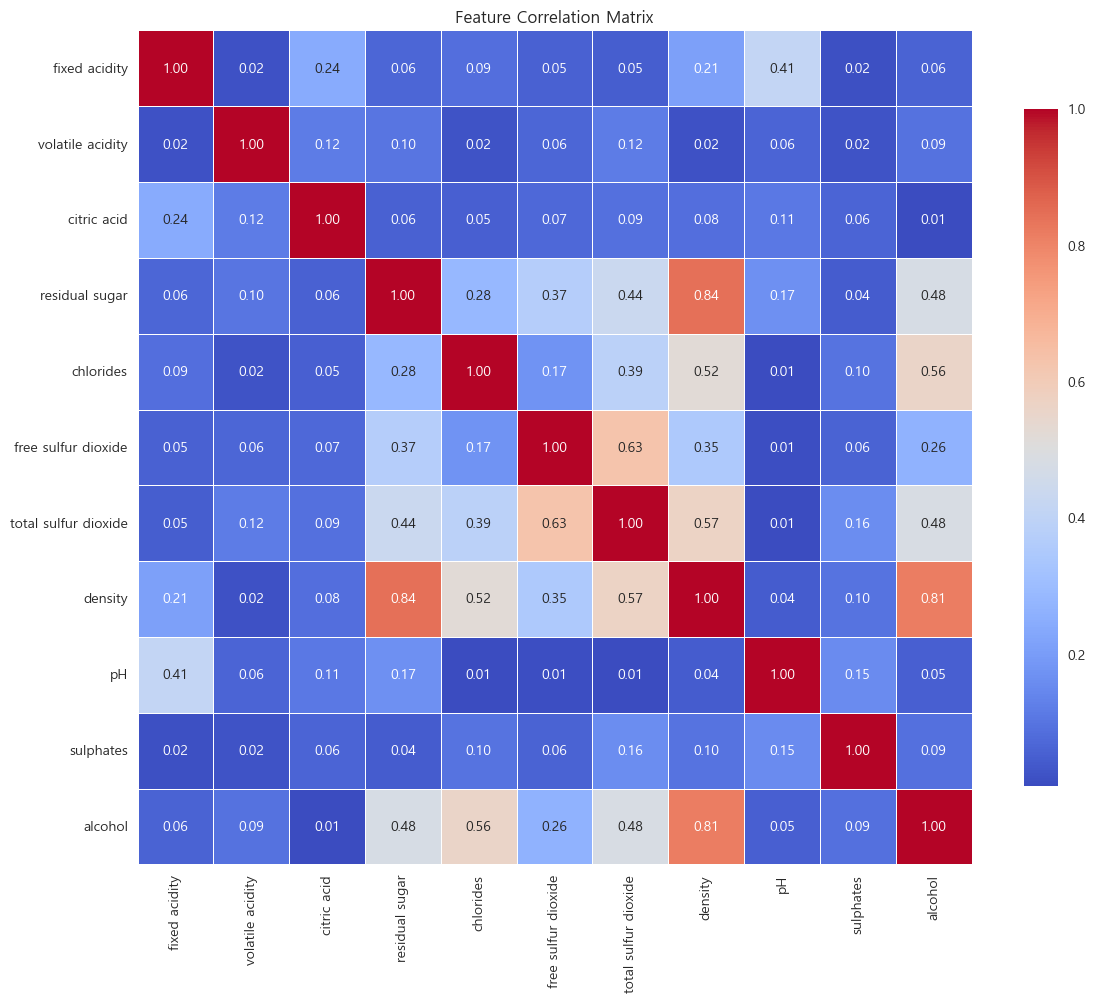

In [10]:
# 피처와 타겟 분리
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

# 상관관계 행렬 계산
corr_matrix = X.corr().abs()

# 상관관계 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


In [11]:
# 높은 상관관계를 가진 피처 쌍 찾기 (다중공선성 문제)
# 상관계수 0.85 이상인 피처 쌍 찾기
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# 높은 상관관계를 가진 피처 쌍 출력
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        if pd.notna(upper_tri.loc[idx, col]) and upper_tri.loc[idx, col] > 0.85:
            high_corr_pairs.append((idx, col, upper_tri.loc[idx, col]))

if high_corr_pairs:
    print("=== 높은 상관관계를 가진 피처 쌍 (상관계수 > 0.85) ===")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"{feat1} <-> {feat2}: {corr_val:.3f}")
else:
    print("높은 상관관계를 가진 피처 쌍이 없습니다.")


높은 상관관계를 가진 피처 쌍이 없습니다.


In [12]:
# 높은 상관관계를 가진 피처 중 하나 제거
# 각 쌍에서 두 번째 피처를 제거 리스트에 추가
to_drop = [column for column in upper_tri.columns 
           if any(upper_tri[column] > 0.85)]

if to_drop:
    print(f"제거할 피처: {to_drop}")
    X_reduced = X.drop(columns=to_drop)
    print(f"\n피처 제거 전: {X.shape[1]}개")
    print(f"피처 제거 후: {X_reduced.shape[1]}개")
else:
    print("제거할 피처가 없습니다.")
    X_reduced = X.copy()


제거할 피처가 없습니다.


## 4-1. Quality와의 상관관계 분석


=== Quality와의 상관관계 (절댓값 기준 내림차순) ===
alcohol                 0.445829
pH                      0.100999
sulphates               0.037350
free sulfur dioxide     0.024621
citric acid            -0.002016
fixed acidity          -0.077658
volatile acidity       -0.101090
residual sugar         -0.127553
total sulfur dioxide   -0.167515
chlorides              -0.288201
density                -0.325193
Name: quality, dtype: float64


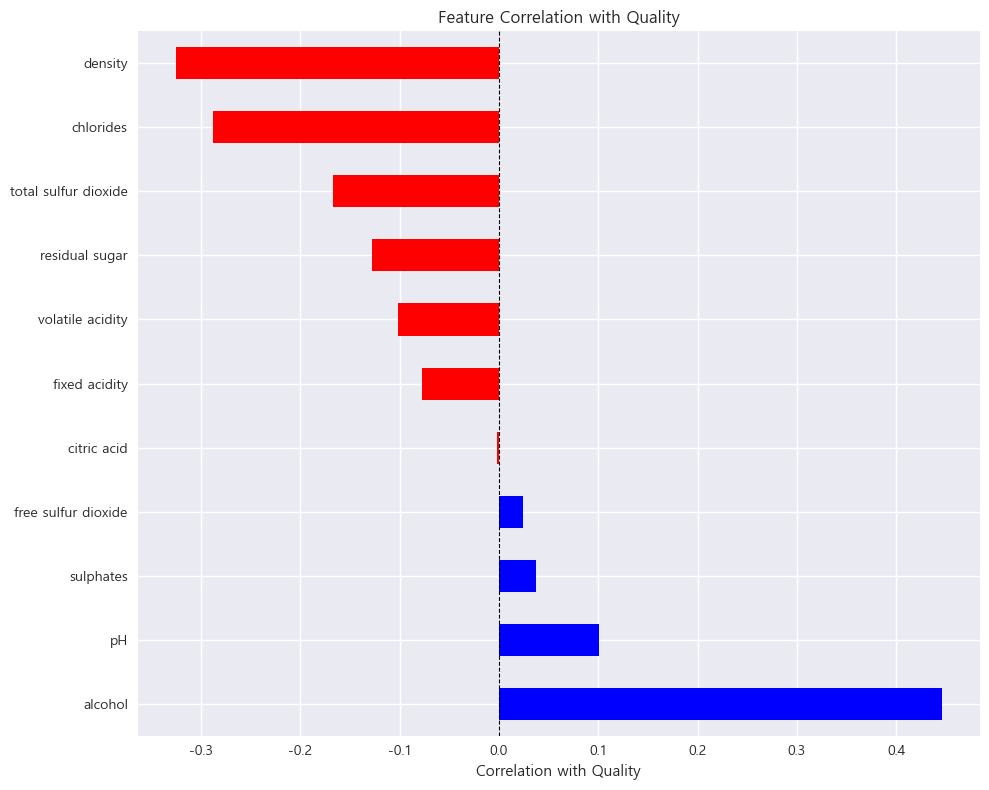


=== 양의 상관관계 피처 (4개) ===
alcohol                0.445829
pH                     0.100999
sulphates              0.037350
free sulfur dioxide    0.024621
Name: quality, dtype: float64

=== 음의 상관관계 피처 (7개) ===
density                -0.325193
chlorides              -0.288201
total sulfur dioxide   -0.167515
residual sugar         -0.127553
volatile acidity       -0.101090
fixed acidity          -0.077658
citric acid            -0.002016
Name: quality, dtype: float64


In [13]:
# Quality와 각 피처 간의 상관관계 계산
quality_corr = df_clean.corr()['quality'].drop('quality').sort_values(ascending=False)

print("=== Quality와의 상관관계 (절댓값 기준 내림차순) ===")
print(quality_corr)

# 상관관계 시각화
plt.figure(figsize=(10, 8))
quality_corr.plot(kind='barh', color=['red' if x < 0 else 'blue' for x in quality_corr.values])
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Correlation with Quality')
plt.title('Feature Correlation with Quality')
plt.tight_layout()
plt.show()

# 양의 상관관계와 음의 상관관계 분류
positive_corr = quality_corr[quality_corr > 0]
negative_corr = quality_corr[quality_corr < 0]

print(f"\n=== 양의 상관관계 피처 ({len(positive_corr)}개) ===")
print(positive_corr.sort_values(ascending=False))

print(f"\n=== 음의 상관관계 피처 ({len(negative_corr)}개) ===")
print(negative_corr.sort_values(ascending=True))


## 4-2. Feature Engineering


In [14]:
# 상관관계가 낮은 피처 확인 (절댓값 기준)
low_corr_threshold = 0.1  # 상관계수 절댓값이 0.1 미만인 피처
low_corr_features = quality_corr[abs(quality_corr) < low_corr_threshold]

print(f"=== Quality와 상관관계가 낮은 피처 (|correlation| < {low_corr_threshold}) ===")
if len(low_corr_features) > 0:
    print(low_corr_features)
    print(f"\n이 피처들은 제거를 고려할 수 있습니다.")
else:
    print("모든 피처가 어느 정도 상관관계를 가지고 있습니다.")


=== Quality와 상관관계가 낮은 피처 (|correlation| < 0.1) ===
sulphates              0.037350
free sulfur dioxide    0.024621
citric acid           -0.002016
fixed acidity         -0.077658
Name: quality, dtype: float64

이 피처들은 제거를 고려할 수 있습니다.


In [15]:
# Feature Engineering 예시
# 1. 상호작용 피처 생성 (높은 상관관계를 가진 피처들의 조합)
# 예: alcohol과 density는 음의 상관관계가 있을 수 있음

# 2. 비율 피처 생성
# 예: free sulfur dioxide / total sulfur dioxide 비율
if 'free sulfur dioxide' in X_reduced.columns and 'total sulfur dioxide' in X_reduced.columns:
    X_reduced['sulfur_ratio'] = X_reduced['free sulfur dioxide'] / (X_reduced['total sulfur dioxide'] + 1e-6)
    print("생성된 피처: sulfur_ratio (free sulfur dioxide / total sulfur dioxide)")

# 3. 산도 관련 피처 조합
if 'fixed acidity' in X_reduced.columns and 'volatile acidity' in X_reduced.columns:
    X_reduced['total_acidity'] = X_reduced['fixed acidity'] + X_reduced['volatile acidity']
    print("생성된 피처: total_acidity (fixed acidity + volatile acidity)")

# 4. 알코올과 당도 관련 피처
if 'alcohol' in X_reduced.columns and 'residual sugar' in X_reduced.columns:
    X_reduced['alcohol_sugar_ratio'] = X_reduced['alcohol'] / (X_reduced['residual sugar'] + 1e-6)
    print("생성된 피처: alcohol_sugar_ratio (alcohol / residual sugar)")

print(f"\nFeature Engineering 후 피처 개수: {X_reduced.shape[1]}개")
print(f"피처 목록: {list(X_reduced.columns)}")


생성된 피처: sulfur_ratio (free sulfur dioxide / total sulfur dioxide)
생성된 피처: total_acidity (fixed acidity + volatile acidity)
생성된 피처: alcohol_sugar_ratio (alcohol / residual sugar)

Feature Engineering 후 피처 개수: 14개
피처 목록: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'sulfur_ratio', 'total_acidity', 'alcohol_sugar_ratio']


In [16]:
# 새로 생성된 피처와 Quality의 상관관계 확인
if X_reduced.shape[1] > len(df_clean.columns) - 1:  # 새 피처가 생성된 경우
    df_temp = pd.concat([X_reduced, y], axis=1)
    new_features = [col for col in X_reduced.columns if col not in df_clean.columns]
    
    print("\n=== 새로 생성된 피처와 Quality의 상관관계 ===")
    for feat in new_features:
        corr_val = df_temp[feat].corr(df_temp['quality'])
        print(f"{feat}: {corr_val:.4f}")



=== 새로 생성된 피처와 Quality의 상관관계 ===
sulfur_ratio: 0.2195
total_acidity: -0.0878
alcohol_sugar_ratio: 0.0675


## 4-3. 피처 선택 (Feature Selection)


In [17]:
# 방법 1: 상관관계 기반 피처 선택
# Quality와의 상관관계가 높은 피처만 선택
corr_threshold = 0.15  # 절댓값 기준 임계값

high_corr_features = quality_corr[abs(quality_corr) >= corr_threshold].index.tolist()
print(f"=== 상관관계 기반 피처 선택 (|correlation| >= {corr_threshold}) ===")
print(f"선택된 피처 개수: {len(high_corr_features)}개")
print(f"선택된 피처: {high_corr_features}")

# 제거될 피처
removed_by_corr = [feat for feat in X_reduced.columns if feat not in high_corr_features]
if removed_by_corr:
    print(f"\n제거될 피처: {removed_by_corr}")
else:
    print("\n모든 피처가 선택되었습니다.")


=== 상관관계 기반 피처 선택 (|correlation| >= 0.15) ===
선택된 피처 개수: 4개
선택된 피처: ['alcohol', 'total sulfur dioxide', 'chlorides', 'density']

제거될 피처: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'free sulfur dioxide', 'pH', 'sulphates', 'sulfur_ratio', 'total_acidity', 'alcohol_sugar_ratio']


In [18]:
# 방법 2: F-검정 기반 피처 선택 (SelectKBest)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler

# 피처 스케일링 (F-검정을 위해 필요)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_reduced),
    columns=X_reduced.columns,
    index=X_reduced.index
)

# F-검정으로 모든 피처의 점수 계산
selector_all = SelectKBest(score_func=f_regression, k='all')
selector_all.fit(X_scaled, y)

# F-점수와 피처 이름 매핑
feature_f_scores = pd.DataFrame({
    'feature': X_scaled.columns,
    'f_score': selector_all.scores_
}).sort_values('f_score', ascending=False)

print("=== F-검정 점수 (F-score) ===")
print(feature_f_scores)

# 상위 N개 피처 선택
n_features = 6  # 선택할 피처 개수
top_features_f = feature_f_scores.head(n_features)['feature'].tolist()
print(f"\n상위 {n_features}개 피처 (F-점수 기준): {top_features_f}")


=== F-검정 점수 (F-score) ===
                 feature     f_score
10               alcohol  816.153768
7                density  389.062291
4              chlorides  298.019348
11          sulfur_ratio  166.508927
6   total sulfur dioxide   94.986535
3         residual sugar   54.413063
1       volatile acidity   33.967944
8                     pH   33.906418
12         total_acidity   25.540509
0          fixed acidity   19.961554
13   alcohol_sugar_ratio   15.071593
9              sulphates    4.596126
5    free sulfur dioxide    1.995543
2            citric acid    0.013367

상위 6개 피처 (F-점수 기준): ['alcohol', 'density', 'chlorides', 'sulfur_ratio', 'total sulfur dioxide', 'residual sugar']


In [19]:
# 방법 3: 상관관계와 F-점수 결합 방법
# 두 방법의 교집합 또는 합집합 사용

# 교집합: 두 방법 모두에서 선택된 피처
intersection_features = list(set(high_corr_features) & set(top_features_f))
print(f"=== 교집합 방법 (상관관계 AND F-점수) ===")
print(f"선택된 피처 개수: {len(intersection_features)}개")
print(f"선택된 피처: {intersection_features}")

# 합집합: 두 방법 중 하나라도 선택된 피처
union_features = list(set(high_corr_features) | set(top_features_f))
print(f"\n=== 합집합 방법 (상관관계 OR F-점수) ===")
print(f"선택된 피처 개수: {len(union_features)}개")
print(f"선택된 피처: {union_features}")

# 최종 선택 방법 결정 (사용자가 선택 가능)
# 예: 상관관계 기반 선택
final_selected_features = high_corr_features.copy()

# 또는 F-점수 기반 선택
# final_selected_features = top_features_f.copy()

# 또는 교집합 사용
# final_selected_features = intersection_features.copy()

print(f"\n=== 최종 선택된 피처 ({len(final_selected_features)}개) ===")
print(final_selected_features)


=== 교집합 방법 (상관관계 AND F-점수) ===
선택된 피처 개수: 4개
선택된 피처: ['chlorides', 'density', 'alcohol', 'total sulfur dioxide']

=== 합집합 방법 (상관관계 OR F-점수) ===
선택된 피처 개수: 6개
선택된 피처: ['residual sugar', 'alcohol', 'density', 'chlorides', 'sulfur_ratio', 'total sulfur dioxide']

=== 최종 선택된 피처 (4개) ===
['alcohol', 'total sulfur dioxide', 'chlorides', 'density']


In [20]:
# 선택된 피처만으로 데이터프레임 재구성
X_final = X_reduced[final_selected_features].copy()

print(f"=== 최종 피처 선택 결과 ===")
print(f"원본 피처 개수: {X_reduced.shape[1]}개")
print(f"선택된 피처 개수: {X_final.shape[1]}개")
print(f"제거된 피처 개수: {X_reduced.shape[1] - X_final.shape[1]}개")
print(f"\n최종 피처 목록: {list(X_final.columns)}")


=== 최종 피처 선택 결과 ===
원본 피처 개수: 14개
선택된 피처 개수: 4개
제거된 피처 개수: 10개

최종 피처 목록: ['alcohol', 'total sulfur dioxide', 'chlorides', 'density']


## 4-4. 추가 피처 선택 방법들 (Univariate, Model-Based, Iterative)


### 방법 4: Univariate Statistics - Mutual Information


In [21]:
# Mutual Information 계산 (비선형 관계도 포착 가능)
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_scaled, y, random_state=42)

mi_df = pd.DataFrame({
    'feature': X_scaled.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("=== Mutual Information 점수 ===")
print(mi_df)

# 상위 N개 피처 선택
n_features_mi = 7
top_features_mi = mi_df.head(n_features_mi)['feature'].tolist()
print(f"\n상위 {n_features_mi}개 피처 (MI 기준): {top_features_mi}")

# F-검정과 Mutual Information 비교
comparison_df = pd.merge(
    feature_f_scores.rename(columns={'f_score': 'f_score'}),
    mi_df.rename(columns={'mi_score': 'mi_score'}),
    on='feature'
)
comparison_df['f_score_norm'] = (comparison_df['f_score'] - comparison_df['f_score'].min()) / (comparison_df['f_score'].max() - comparison_df['f_score'].min() + 1e-10)
comparison_df['mi_score_norm'] = (comparison_df['mi_score'] - comparison_df['mi_score'].min()) / (comparison_df['mi_score'].max() - comparison_df['mi_score'].min() + 1e-10)

print("\n=== F-검정 vs Mutual Information 비교 ===")
print(comparison_df[['feature', 'f_score', 'mi_score']].sort_values('f_score', ascending=False))


=== Mutual Information 점수 ===
                 feature  mi_score
13   alcohol_sugar_ratio  0.193822
7                density  0.188871
11          sulfur_ratio  0.173145
10               alcohol  0.161731
3         residual sugar  0.108325
6   total sulfur dioxide  0.095744
5    free sulfur dioxide  0.074262
12         total_acidity  0.064739
4              chlorides  0.057193
8                     pH  0.042652
2            citric acid  0.035816
1       volatile acidity  0.029742
9              sulphates  0.022114
0          fixed acidity  0.013996

상위 7개 피처 (MI 기준): ['alcohol_sugar_ratio', 'density', 'sulfur_ratio', 'alcohol', 'residual sugar', 'total sulfur dioxide', 'free sulfur dioxide']

=== F-검정 vs Mutual Information 비교 ===
                 feature     f_score  mi_score
0                alcohol  816.153768  0.161731
1                density  389.062291  0.188871
2              chlorides  298.019348  0.057193
3           sulfur_ratio  166.508927  0.173145
4   total sulfur dioxide 

### 방법 5: Univariate Statistics - Variance Threshold


In [22]:
# 분산이 낮은 피처 제거 (거의 변하지 않는 피처)
from sklearn.feature_selection import VarianceThreshold

# 원본 데이터(스케일링 전)의 분산 확인
feature_variances = pd.DataFrame({
    'feature': X_reduced.columns,
    'variance': X_reduced.var()
}).sort_values('variance', ascending=True)

print("=== 피처별 분산 (원본 스케일) ===")
print(feature_variances)

# 분산이 낮아 제거될 피처 (임계값: 전체 분산의 1%)
variance_threshold = X_reduced.var().quantile(0.01)
low_variance_features = feature_variances[feature_variances['variance'] < variance_threshold]['feature'].tolist()

if low_variance_features:
    print(f"\n분산이 낮아 제거를 고려할 피처 (임계값: {variance_threshold:.6f}): {low_variance_features}")
else:
    print(f"\n모든 피처의 분산이 충분합니다. (임계값: {variance_threshold:.6f})")


=== 피처별 분산 (원본 스케일) ===
                                   feature     variance
density                            density     0.000008
chlorides                        chlorides     0.000100
volatile acidity          volatile acidity     0.005827
sulfur_ratio                  sulfur_ratio     0.007657
citric acid                    citric acid     0.007800
sulphates                        sulphates     0.009887
pH                                      pH     0.020028
fixed acidity                fixed acidity     0.549828
total_acidity                total_acidity     0.553551
alcohol                            alcohol     1.439801
alcohol_sugar_ratio    alcohol_sugar_ratio    10.792276
residual sugar              residual sugar    24.003826
free sulfur dioxide    free sulfur dioxide   227.824858
total sulfur dioxide  total sulfur dioxide  1796.878595

분산이 낮아 제거를 고려할 피처 (임계값: 0.000020): ['density']


### 방법 6: Model-Based Selection - RandomForest Feature Importance


=== RandomForest Feature Importance ===
                 feature  importance
10               alcohol    0.229569
1       volatile acidity    0.099406
11          sulfur_ratio    0.085041
8                     pH    0.075646
5    free sulfur dioxide    0.073251
6   total sulfur dioxide    0.060102
4              chlorides    0.057782
9              sulphates    0.054705
7                density    0.053310
12         total_acidity    0.050275
13   alcohol_sugar_ratio    0.050094
2            citric acid    0.044794
3         residual sugar    0.039602
0          fixed acidity    0.026424

상위 7개 피처 (RF Importance 기준): ['alcohol', 'volatile acidity', 'sulfur_ratio', 'pH', 'free sulfur dioxide', 'total sulfur dioxide', 'chlorides']


<Figure size 1000x600 with 0 Axes>

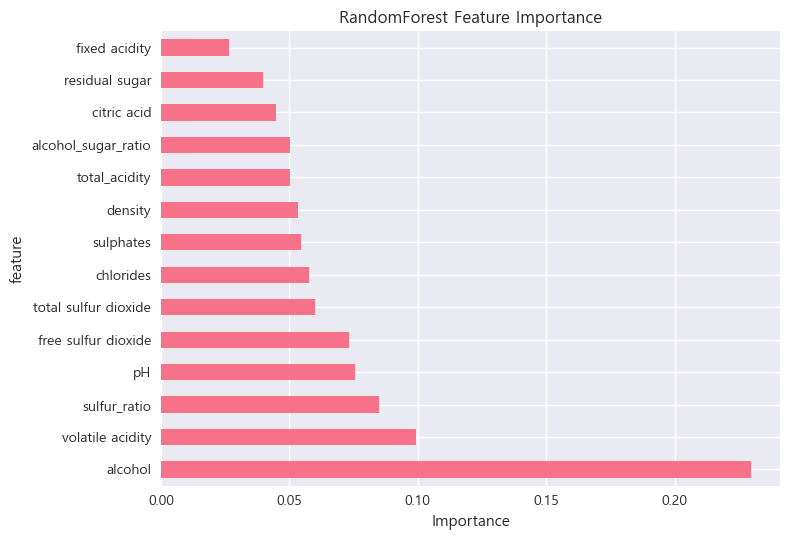

In [23]:
# RandomForest 모델 기반 피처 중요도
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Train/Test 분리 (피처 중요도 계산용)
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# RandomForest 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_temp, y_train_temp)

# 피처 중요도 추출
rf_importance = pd.DataFrame({
    'feature': X_scaled.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== RandomForest Feature Importance ===")
print(rf_importance)

# 상위 N개 피처 선택
n_features_rf = 7
top_features_rf = rf_importance.head(n_features_rf)['feature'].tolist()
print(f"\n상위 {n_features_rf}개 피처 (RF Importance 기준): {top_features_rf}")

# 중요도 시각화
plt.figure(figsize=(10, 6))
rf_importance.plot(x='feature', y='importance', kind='barh', legend=False)
plt.xlabel('Importance')
plt.title('RandomForest Feature Importance')
plt.tight_layout()
plt.show()


### 방법 7: Model-Based Selection - Lasso (L1 Regularization)


=== Lasso 최적 alpha: 0.001119 ===

=== Lasso 계수 (절댓값 기준) ===
                 feature  coefficient  abs_coefficient
7                density    -0.497126         0.497126
3         residual sugar     0.319419         0.319419
11          sulfur_ratio     0.290555         0.290555
5    free sulfur dioxide    -0.259841         0.259841
6   total sulfur dioxide     0.222393         0.222393
10               alcohol     0.197277         0.197277
8                     pH     0.135057         0.135057
13   alcohol_sugar_ratio    -0.126478         0.126478
1       volatile acidity    -0.124110         0.124110
9              sulphates     0.086200         0.086200
0          fixed acidity     0.084410         0.084410
4              chlorides    -0.029569         0.029569
2            citric acid    -0.000000         0.000000
12         total_acidity     0.000000         0.000000

Lasso가 선택한 피처 (12개): ['density', 'residual sugar', 'sulfur_ratio', 'free sulfur dioxide', 'total sulfur dioxide', 

<Figure size 1000x600 with 0 Axes>

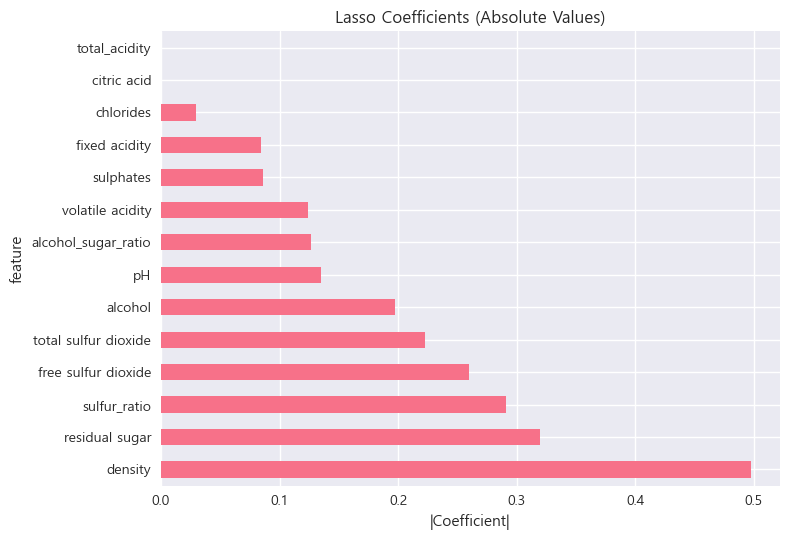

In [24]:
# LassoCV로 최적 alpha 찾기 및 피처 선택
from sklearn.linear_model import LassoCV

# LassoCV로 최적 alpha 찾기
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=1000, n_jobs=-1)
lasso_cv.fit(X_scaled, y)

print(f"=== Lasso 최적 alpha: {lasso_cv.alpha_:.6f} ===")

# Lasso 계수 추출
lasso_coef = pd.DataFrame({
    'feature': X_scaled.columns,
    'coefficient': lasso_cv.coef_,
    'abs_coefficient': np.abs(lasso_cv.coef_)
}).sort_values('abs_coefficient', ascending=False)

print("\n=== Lasso 계수 (절댓값 기준) ===")
print(lasso_coef)

# 계수가 0이 아닌 피처 (Lasso가 선택한 피처)
selected_by_lasso = lasso_coef[lasso_coef['coefficient'] != 0]['feature'].tolist()
print(f"\nLasso가 선택한 피처 ({len(selected_by_lasso)}개): {selected_by_lasso}")

# 계수가 0인 피처 (제거된 피처)
removed_by_lasso = lasso_coef[lasso_coef['coefficient'] == 0]['feature'].tolist()
if removed_by_lasso:
    print(f"Lasso가 제거한 피처 ({len(removed_by_lasso)}개): {removed_by_lasso}")

# 계수 시각화
plt.figure(figsize=(10, 6))
lasso_coef.plot(x='feature', y='abs_coefficient', kind='barh', legend=False)
plt.xlabel('|Coefficient|')
plt.title('Lasso Coefficients (Absolute Values)')
plt.tight_layout()
plt.show()


### 방법 8: Model-Based Selection - Permutation Importance


=== Permutation Importance ===
                 feature  importance_mean  importance_std
10               alcohol         0.540342        0.030259
1       volatile acidity         0.143037        0.010151
8                     pH         0.059267        0.008144
11          sulfur_ratio         0.052752        0.010007
5    free sulfur dioxide         0.047458        0.008384
9              sulphates         0.043205        0.005447
4              chlorides         0.040517        0.004897
7                density         0.036519        0.004408
6   total sulfur dioxide         0.033127        0.006122
2            citric acid         0.026936        0.003720
12         total_acidity         0.026233        0.004304
13   alcohol_sugar_ratio         0.023883        0.004788
3         residual sugar         0.021385        0.004944
0          fixed acidity         0.008228        0.002967

상위 7개 피처 (Permutation Importance 기준): ['alcohol', 'volatile acidity', 'pH', 'sulfur_ratio', 'free 

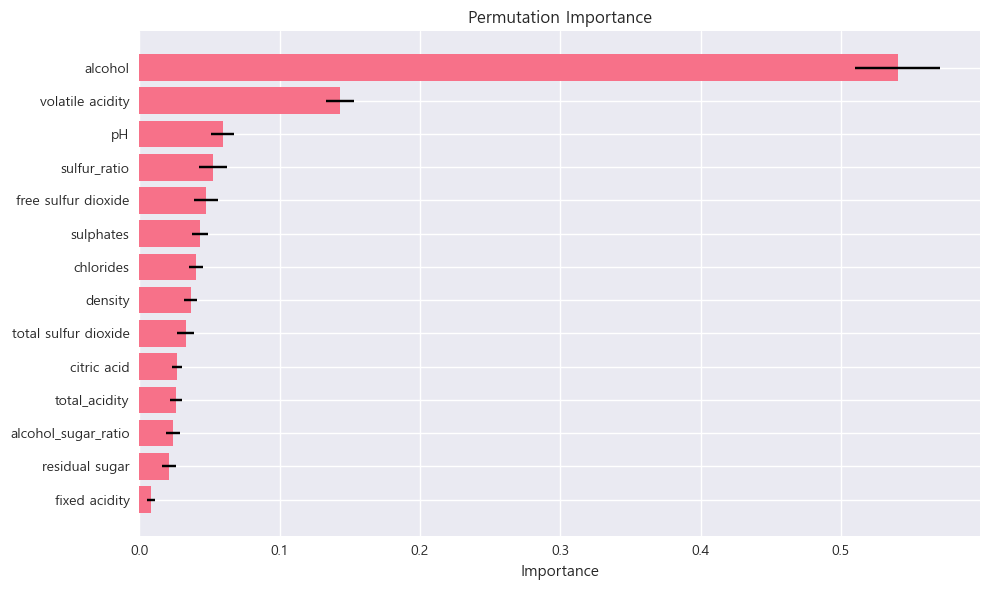

In [25]:
# Permutation Importance 계산
from sklearn.inspection import permutation_importance

# Permutation Importance 계산
perm_importance = permutation_importance(
    rf_model, X_test_temp, y_test_temp, 
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_scaled.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("=== Permutation Importance ===")
print(perm_df)

# 상위 N개 피처 선택
n_features_perm = 7
top_features_perm = perm_df.head(n_features_perm)['feature'].tolist()
print(f"\n상위 {n_features_perm}개 피처 (Permutation Importance 기준): {top_features_perm}")

# 중요도 시각화 (오차막대 포함)
plt.figure(figsize=(10, 6))
plt.barh(range(len(perm_df)), perm_df['importance_mean'], xerr=perm_df['importance_std'])
plt.yticks(range(len(perm_df)), perm_df['feature'])
plt.xlabel('Importance')
plt.title('Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 방법 9: Iterative Selection - RFE (Recursive Feature Elimination)


In [26]:
# RFE를 사용한 피처 선택
from sklearn.feature_selection import RFE

# RFE를 사용한 피처 선택
n_features_rfe = 7
rfe_selector = RFE(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    n_features_to_select=n_features_rfe,
    step=1  # 한 번에 하나씩 제거
)
rfe_selector.fit(X_scaled, y)

# 선택된 피처
rfe_selected = pd.DataFrame({
    'feature': X_scaled.columns,
    'selected': rfe_selector.support_,
    'ranking': rfe_selector.ranking_
}).sort_values('ranking')

print(f"=== RFE 결과 (목표: {n_features_rfe}개 피처) ===")
print(rfe_selected)

top_features_rfe = rfe_selected[rfe_selected['selected']]['feature'].tolist()
print(f"\nRFE가 선택한 피처 ({len(top_features_rfe)}개): {top_features_rfe}")


=== RFE 결과 (목표: 7개 피처) ===
                 feature  selected  ranking
1       volatile acidity      True        1
5    free sulfur dioxide      True        1
10               alcohol      True        1
13   alcohol_sugar_ratio      True        1
12         total_acidity      True        1
11          sulfur_ratio      True        1
8                     pH      True        1
7                density     False        2
6   total sulfur dioxide     False        3
4              chlorides     False        4
9              sulphates     False        5
2            citric acid     False        6
3         residual sugar     False        7
0          fixed acidity     False        8

RFE가 선택한 피처 (7개): ['volatile acidity', 'free sulfur dioxide', 'alcohol', 'alcohol_sugar_ratio', 'total_acidity', 'sulfur_ratio', 'pH']


### 방법 10: Iterative Selection - RFECV (RFE with Cross-Validation)


=== RFECV 최적 피처 개수: 14개 ===

=== RFECV 결과 ===
                 feature  selected  ranking
0          fixed acidity      True        1
1       volatile acidity      True        1
2            citric acid      True        1
3         residual sugar      True        1
4              chlorides      True        1
5    free sulfur dioxide      True        1
6   total sulfur dioxide      True        1
7                density      True        1
8                     pH      True        1
9              sulphates      True        1
10               alcohol      True        1
11          sulfur_ratio      True        1
12         total_acidity      True        1
13   alcohol_sugar_ratio      True        1

RFECV가 선택한 피처 (14개): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'sulfur_ratio', 'total_acidity', 'alcohol_sugar_ratio']


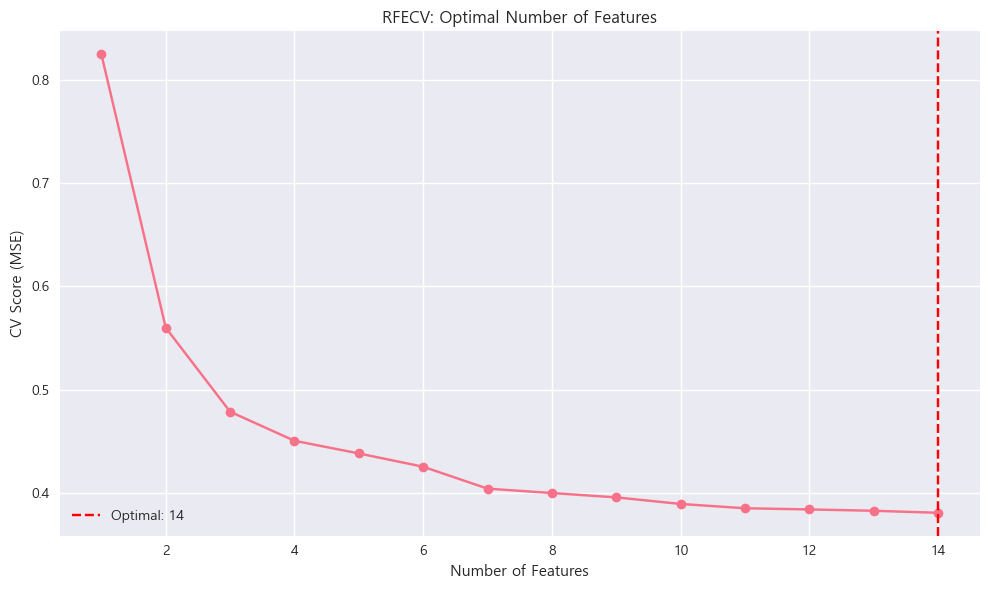

In [27]:
# RFECV를 사용한 최적 피처 개수 찾기
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold

# RFECV를 사용한 최적 피처 개수 찾기
rfecv_selector = RFECV(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    step=1,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
rfecv_selector.fit(X_scaled, y)

print(f"=== RFECV 최적 피처 개수: {rfecv_selector.n_features_}개 ===")

# 선택된 피처
rfecv_selected = pd.DataFrame({
    'feature': X_scaled.columns,
    'selected': rfecv_selector.support_,
    'ranking': rfecv_selector.ranking_
}).sort_values('ranking')

print("\n=== RFECV 결과 ===")
print(rfecv_selected)

top_features_rfecv = rfecv_selected[rfecv_selected['selected']]['feature'].tolist()
print(f"\nRFECV가 선택한 피처 ({len(top_features_rfecv)}개): {top_features_rfecv}")

# 교차검증 점수 시각화
plt.figure(figsize=(10, 6))
n_features_range = range(1, len(rfecv_selector.cv_results_['mean_test_score']) + 1)
plt.plot(n_features_range, -rfecv_selector.cv_results_['mean_test_score'], 'o-')
plt.xlabel('Number of Features')
plt.ylabel('CV Score (MSE)')
plt.title('RFECV: Optimal Number of Features')
plt.grid(True)
plt.axvline(x=rfecv_selector.n_features_, color='r', linestyle='--', label=f'Optimal: {rfecv_selector.n_features_}')
plt.legend()
plt.tight_layout()
plt.show()


### 모든 방법 비교 및 종합 분석


=== 모든 피처 선택 방법 비교 ===

각 방법별 선택된 피처:

상관관계 기반: 4개
  ['density', 'alcohol', 'chlorides', 'total sulfur dioxide']

F-검정: 6개
  ['residual sugar', 'alcohol', 'density', 'chlorides', 'sulfur_ratio', 'total sulfur dioxide']

Mutual Information: 7개
  ['residual sugar', 'alcohol', 'density', 'free sulfur dioxide', 'sulfur_ratio', 'total sulfur dioxide', 'alcohol_sugar_ratio']

RandomForest Importance: 7개
  ['pH', 'alcohol', 'volatile acidity', 'free sulfur dioxide', 'chlorides', 'sulfur_ratio', 'total sulfur dioxide']

Lasso: 12개
  ['residual sugar', 'pH', 'alcohol', 'volatile acidity', 'sulphates', 'density', 'fixed acidity', 'free sulfur dioxide', 'chlorides', 'sulfur_ratio', 'total sulfur dioxide', 'alcohol_sugar_ratio']

Permutation Importance: 7개
  ['pH', 'alcohol', 'volatile acidity', 'sulphates', 'free sulfur dioxide', 'chlorides', 'sulfur_ratio']

RFE: 7개
  ['pH', 'volatile acidity', 'alcohol', 'total_acidity', 'free sulfur dioxide', 'sulfur_ratio', 'alcohol_sugar_ratio']

RFECV: 14개


<Figure size 1000x600 with 0 Axes>

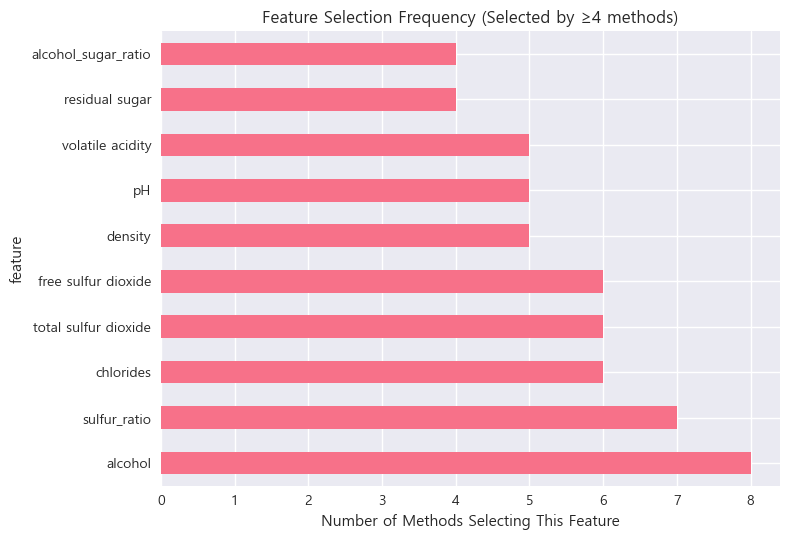

In [28]:
# 모든 방법의 결과를 종합하여 비교
print("=" * 80)
print("=== 모든 피처 선택 방법 비교 ===")
print("=" * 80)

methods_comparison = {
    '상관관계 기반': set(high_corr_features),
    'F-검정': set(top_features_f),
    'Mutual Information': set(top_features_mi),
    'RandomForest Importance': set(top_features_rf),
    'Lasso': set(selected_by_lasso),
    'Permutation Importance': set(top_features_perm),
    'RFE': set(top_features_rfe),
    'RFECV': set(top_features_rfecv)
}

# 각 방법별 선택된 피처 출력
print("\n각 방법별 선택된 피처:")
for method, features in methods_comparison.items():
    print(f"\n{method}: {len(features)}개")
    print(f"  {list(features)}")

# 모든 방법에서 공통으로 선택된 피처 (교집합)
if len(methods_comparison) > 0:
    common_features = set.intersection(*methods_comparison.values())
    print(f"\n{'=' * 80}")
    print(f"=== 모든 방법에서 공통 선택된 피처 ({len(common_features)}개) ===")
    print(f"{'=' * 80}")
    if common_features:
        print(list(common_features))
    else:
        print("공통으로 선택된 피처가 없습니다.")
    
    # 대부분의 방법에서 선택된 피처 (절반 이상 방법에서 선택)
    from collections import Counter
    all_selected_features = []
    for features in methods_comparison.values():
        all_selected_features.extend(list(features))
    
    feature_counts = Counter(all_selected_features)
    n_methods = len(methods_comparison)
    threshold = max(1, n_methods // 2)  # 절반 이상
    
    most_selected = [(feat, count) for feat, count in feature_counts.items() if count >= threshold]
    most_selected.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n{'=' * 80}")
    print(f"=== {threshold}개 이상 방법에서 선택된 피처 ===")
    print(f"{'=' * 80}")
    for feat, count in most_selected:
        print(f"{feat}: {count}개 방법에서 선택")
    
    # 피처 선택 빈도 시각화
    feature_freq_df = pd.DataFrame(most_selected, columns=['feature', 'frequency'])
    if len(feature_freq_df) > 0:
        plt.figure(figsize=(10, 6))
        feature_freq_df.plot(x='feature', y='frequency', kind='barh', legend=False)
        plt.xlabel('Number of Methods Selecting This Feature')
        plt.title(f'Feature Selection Frequency (Selected by ≥{threshold} methods)')
        plt.tight_layout()
        plt.show()


In [29]:
# 전처리가 필요한 피처 식별
print("=" * 80)
print("=== 전처리가 필요한 피처 분석 ===")
print("=" * 80)

# 1. 대부분의 방법에서 제거된 피처 (선택 빈도가 낮은 피처)
all_features = set(X_scaled.columns)
low_selected_features = []
for feat in all_features:
    count = feature_counts.get(feat, 0)
    if count < threshold:
        low_selected_features.append((feat, count))

low_selected_features.sort(key=lambda x: x[1])

print(f"\n선택 빈도가 낮은 피처 ({threshold}개 미만 방법에서 선택):")
for feat, count in low_selected_features:
    print(f"  {feat}: {count}개 방법에서 선택")

# 2. 분산이 낮은 피처
if low_variance_features:
    print(f"\n분산이 낮은 피처 (제거 고려):")
    for feat in low_variance_features:
        print(f"  {feat}")

# 3. Lasso에서 제거된 피처
if removed_by_lasso:
    print(f"\nLasso에서 제거된 피처 (계수 = 0):")
    for feat in removed_by_lasso:
        print(f"  {feat}")

# 4. 상관관계가 낮은 피처
if len(low_corr_features) > 0:
    print(f"\nQuality와 상관관계가 낮은 피처 (|correlation| < {low_corr_threshold}):")
    for feat in low_corr_features.index:
        print(f"  {feat}: {low_corr_features[feat]:.4f}")

# 종합: 전처리 권장 피처
preprocessing_candidates = set()
if low_selected_features:
    preprocessing_candidates.update([feat for feat, _ in low_selected_features])
if low_variance_features:
    preprocessing_candidates.update(low_variance_features)
if removed_by_lasso:
    preprocessing_candidates.update(removed_by_lasso)
if len(low_corr_features) > 0:
    preprocessing_candidates.update(low_corr_features.index)

print(f"\n{'=' * 80}")
print(f"=== 전처리 권장 피처 종합 ({len(preprocessing_candidates)}개) ===")
print(f"{'=' * 80}")
if preprocessing_candidates:
    print("다음 피처들은 제거 또는 변환을 고려해볼 수 있습니다:")
    for feat in sorted(preprocessing_candidates):
        reasons = []
        if feat in [f for f, _ in low_selected_features]:
            reasons.append("선택 빈도 낮음")
        if feat in low_variance_features:
            reasons.append("분산 낮음")
        if feat in removed_by_lasso:
            reasons.append("Lasso 제거")
        if feat in low_corr_features.index:
            reasons.append("상관관계 낮음")
        print(f"  {feat}: {', '.join(reasons)}")
else:
    print("모든 피처가 유용해 보입니다.")


=== 전처리가 필요한 피처 분석 ===

선택 빈도가 낮은 피처 (4개 미만 방법에서 선택):
  citric acid: 1개 방법에서 선택
  total_acidity: 2개 방법에서 선택
  fixed acidity: 2개 방법에서 선택
  sulphates: 3개 방법에서 선택

분산이 낮은 피처 (제거 고려):
  density

Lasso에서 제거된 피처 (계수 = 0):
  citric acid
  total_acidity

Quality와 상관관계가 낮은 피처 (|correlation| < 0.1):
  sulphates: 0.0374
  free sulfur dioxide: 0.0246
  citric acid: -0.0020
  fixed acidity: -0.0777

=== 전처리 권장 피처 종합 (6개) ===
다음 피처들은 제거 또는 변환을 고려해볼 수 있습니다:
  citric acid: 선택 빈도 낮음, Lasso 제거, 상관관계 낮음
  density: 분산 낮음
  fixed acidity: 선택 빈도 낮음, 상관관계 낮음
  free sulfur dioxide: 상관관계 낮음
  sulphates: 선택 빈도 낮음, 상관관계 낮음
  total_acidity: 선택 빈도 낮음, Lasso 제거


## 5. 전처리 결과 요약 및 저장


In [30]:
# 최종 전처리된 데이터 (피처 선택 후)
df_preprocessed = pd.concat([X_final, y], axis=1)

print("=== 전처리 결과 요약 ===")
print(f"원본 데이터 크기: {df.shape}")
print(f"전처리 후 데이터 크기: {df_preprocessed.shape}")
print(f"\n제거된 행 수: {df.shape[0] - df_preprocessed.shape[0]}개")
print(f"제거된 피처 수: {df.shape[1] - df_preprocessed.shape[1]}개")
print(f"\n최종 선택된 피처 목록 ({len(X_final.columns)}개): {list(X_final.columns)}")
print(f"\n최종 데이터 샘플:")
df_preprocessed.head()


=== 전처리 결과 요약 ===
원본 데이터 크기: (4001, 12)
전처리 후 데이터 크기: (3292, 5)

제거된 행 수: 709개
제거된 피처 수: 7개

최종 선택된 피처 목록 (4개): ['alcohol', 'total sulfur dioxide', 'chlorides', 'density']

최종 데이터 샘플:


,alcohol,total sulfur dioxide,chlorides,density,quality
0,8.8,170.0,0.045,1.0010,6
1,9.5,132.0,0.049,0.9940,6
2,10.1,97.0,0.050,0.9951,6
3,9.9,186.0,0.058,0.9956,6
4,9.9,186.0,0.058,0.9956,6


In [31]:
# 전처리된 데이터 저장 (선택사항)
# df_preprocessed.to_csv('wine_data_preprocessed.csv', index=False)
# print("전처리된 데이터가 'wine_data_preprocessed.csv'로 저장되었습니다.")


## 5-1. 정규화 방법 비교 및 최적화


### 1. 여러 정규화 방법 적용


In [32]:
# 여러 정규화 방법 적용
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer, PowerTransformer
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 피처와 타겟 분리
X_features = X_final.copy()
y_target = y.copy()

print("=== 적용할 정규화 방법 ===")
print("1. None (정규화 없음 - Baseline)")
print("2. StandardScaler (평균 0, 표준편차 1)")
print("3. MinMaxScaler (0~1 범위)")
print("4. RobustScaler (중앙값과 IQR 기반)")
print("5. QuantileTransformer (정규분포 변환)")
print("6. PowerTransformer (Yeo-Johnson 변환)")

# 각 정규화 방법 적용
normalization_methods = {
    'None (Baseline)': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'QuantileTransformer': QuantileTransformer(output_distribution='normal', random_state=42),
    'PowerTransformer': PowerTransformer(method='yeo-johnson', standardize=True)
}

# 정규화된 데이터 저장
normalized_data = {}

for method_name, scaler in normalization_methods.items():
    if scaler is None:
        # 정규화 없음
        normalized_data[method_name] = X_features.copy()
    else:
        # 정규화 적용
        normalized_data[method_name] = pd.DataFrame(
            scaler.fit_transform(X_features),
            columns=X_features.columns,
            index=X_features.index
        )
    
    print(f"\n{method_name} 적용 완료")
    print(f"  데이터 형태: {normalized_data[method_name].shape}")
    print(f"  통계 요약:")
    print(f"    평균: {normalized_data[method_name].mean().round(4).tolist()}")
    print(f"    표준편차: {normalized_data[method_name].std().round(4).tolist()}")


=== 적용할 정규화 방법 ===
1. None (정규화 없음 - Baseline)
2. StandardScaler (평균 0, 표준편차 1)
3. MinMaxScaler (0~1 범위)
4. RobustScaler (중앙값과 IQR 기반)
5. QuantileTransformer (정규분포 변환)
6. PowerTransformer (Yeo-Johnson 변환)

None (Baseline) 적용 완료
  데이터 형태: (3292, 4)
  통계 요약:
    평균: [10.5354, 139.0573, 0.042, 0.994]
    표준편차: [1.1999, 42.3896, 0.01, 0.0029]

StandardScaler 적용 완료
  데이터 형태: (3292, 4)
  통계 요약:
    평균: [0.0, -0.0, -0.0, 0.0]
    표준편차: [1.0002, 1.0002, 1.0002, 1.0002]

MinMaxScaler 적용 완료
  데이터 형태: (3292, 4)
  통계 요약:
    평균: [0.3813, 0.5066, 0.4828, 0.4639]
    표준편차: [0.2143, 0.1789, 0.1784, 0.1931]

RobustScaler 적용 완료
  데이터 형태: (3292, 4)
  통계 요약:
    평균: [0.0712, 0.0747, 0.0028, 0.0726]
    표준편차: [0.6315, 0.6949, 0.7135, 0.6701]

QuantileTransformer 적용 완료
  데이터 형태: (3292, 4)
  통계 요약:
    평균: [0.0008, 0.0008, -0.0002, -0.0001]
    표준편차: [1.0082, 1.0085, 1.0087, 1.0058]

PowerTransformer 적용 완료
  데이터 형태: (3292, 4)
  통계 요약:
    평균: [0.0, 0.0, 0.0, -0.0]
    표준편차: [1.0002, 1.0002, 1.0002, 0.0]


### 2. 모델 학습 및 교차검증 평가


In [33]:
# 여러 모델 정의
models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42)
}

# 교차검증 설정
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 결과 저장용 딕셔너리
results = []

print("=" * 100)
print("정규화 방법별 모델 성능 평가 (5-Fold Cross-Validation)")
print("=" * 100)

# 각 정규화 방법과 모델 조합에 대해 평가
for norm_method, X_norm in normalized_data.items():
    print(f"\n{'='*100}")
    print(f"정규화 방법: {norm_method}")
    print(f"{'='*100}")
    
    for model_name, model in models.items():
        # 교차검증으로 여러 지표 계산
        # MSE (neg_mean_squared_error를 사용하므로 음수)
        mse_scores = -cross_val_score(model, X_norm, y_target, cv=cv, 
                                      scoring='neg_mean_squared_error', n_jobs=-1)
        rmse_scores = np.sqrt(mse_scores)
        
        # R² Score
        r2_scores = cross_val_score(model, X_norm, y_target, cv=cv, 
                                    scoring='r2', n_jobs=-1)
        
        # MAE (neg_mean_absolute_error를 사용하므로 음수)
        mae_scores = -cross_val_score(model, X_norm, y_target, cv=cv, 
                                     scoring='neg_mean_absolute_error', n_jobs=-1)
        
        # 결과 저장
        results.append({
            'normalization': norm_method,
            'model': model_name,
            'mse_mean': mse_scores.mean(),
            'mse_std': mse_scores.std(),
            'rmse_mean': rmse_scores.mean(),
            'rmse_std': rmse_scores.std(),
            'r2_mean': r2_scores.mean(),
            'r2_std': r2_scores.std(),
            'mae_mean': mae_scores.mean(),
            'mae_std': mae_scores.std()
        })
        
        # 결과 출력
        print(f"\n{model_name}:")
        print(f"  MSE:  {mse_scores.mean():.4f} (+/- {mse_scores.std()*2:.4f})")
        print(f"  RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std()*2:.4f})")
        print(f"  R²:   {r2_scores.mean():.4f} (+/- {r2_scores.std()*2:.4f})")
        print(f"  MAE:  {mae_scores.mean():.4f} (+/- {mae_scores.std()*2:.4f})")

# 결과를 DataFrame으로 변환
results_df = pd.DataFrame(results)
print(f"\n{'='*100}")
print("전체 결과 요약")
print(f"{'='*100}")
print(results_df.to_string(index=False))


정규화 방법별 모델 성능 평가 (5-Fold Cross-Validation)

정규화 방법: None (Baseline)

RandomForest:
  MSE:  0.4581 (+/- 0.0558)
  RMSE: 0.6765 (+/- 0.0413)
  R²:   0.4095 (+/- 0.0360)
  MAE:  0.4885 (+/- 0.0208)

LinearRegression:
  MSE:  0.6177 (+/- 0.1021)
  RMSE: 0.7853 (+/- 0.0646)
  R²:   0.2044 (+/- 0.0765)
  MAE:  0.6220 (+/- 0.0433)

Ridge:
  MSE:  0.6211 (+/- 0.1025)
  RMSE: 0.7874 (+/- 0.0646)
  R²:   0.1999 (+/- 0.0831)
  MAE:  0.6241 (+/- 0.0439)

정규화 방법: StandardScaler

RandomForest:
  MSE:  0.4584 (+/- 0.0550)
  RMSE: 0.6768 (+/- 0.0406)
  R²:   0.4091 (+/- 0.0372)
  MAE:  0.4888 (+/- 0.0204)

LinearRegression:
  MSE:  0.6177 (+/- 0.1021)
  RMSE: 0.7853 (+/- 0.0646)
  R²:   0.2044 (+/- 0.0765)
  MAE:  0.6220 (+/- 0.0433)

Ridge:
  MSE:  0.6177 (+/- 0.1021)
  RMSE: 0.7853 (+/- 0.0646)
  R²:   0.2044 (+/- 0.0765)
  MAE:  0.6220 (+/- 0.0433)

정규화 방법: MinMaxScaler

RandomForest:
  MSE:  0.4584 (+/- 0.0553)
  RMSE: 0.6767 (+/- 0.0409)
  R²:   0.4091 (+/- 0.0368)
  MAE:  0.4884 (+/- 0.0208)

Li

### 3. 결과 시각화 및 분석


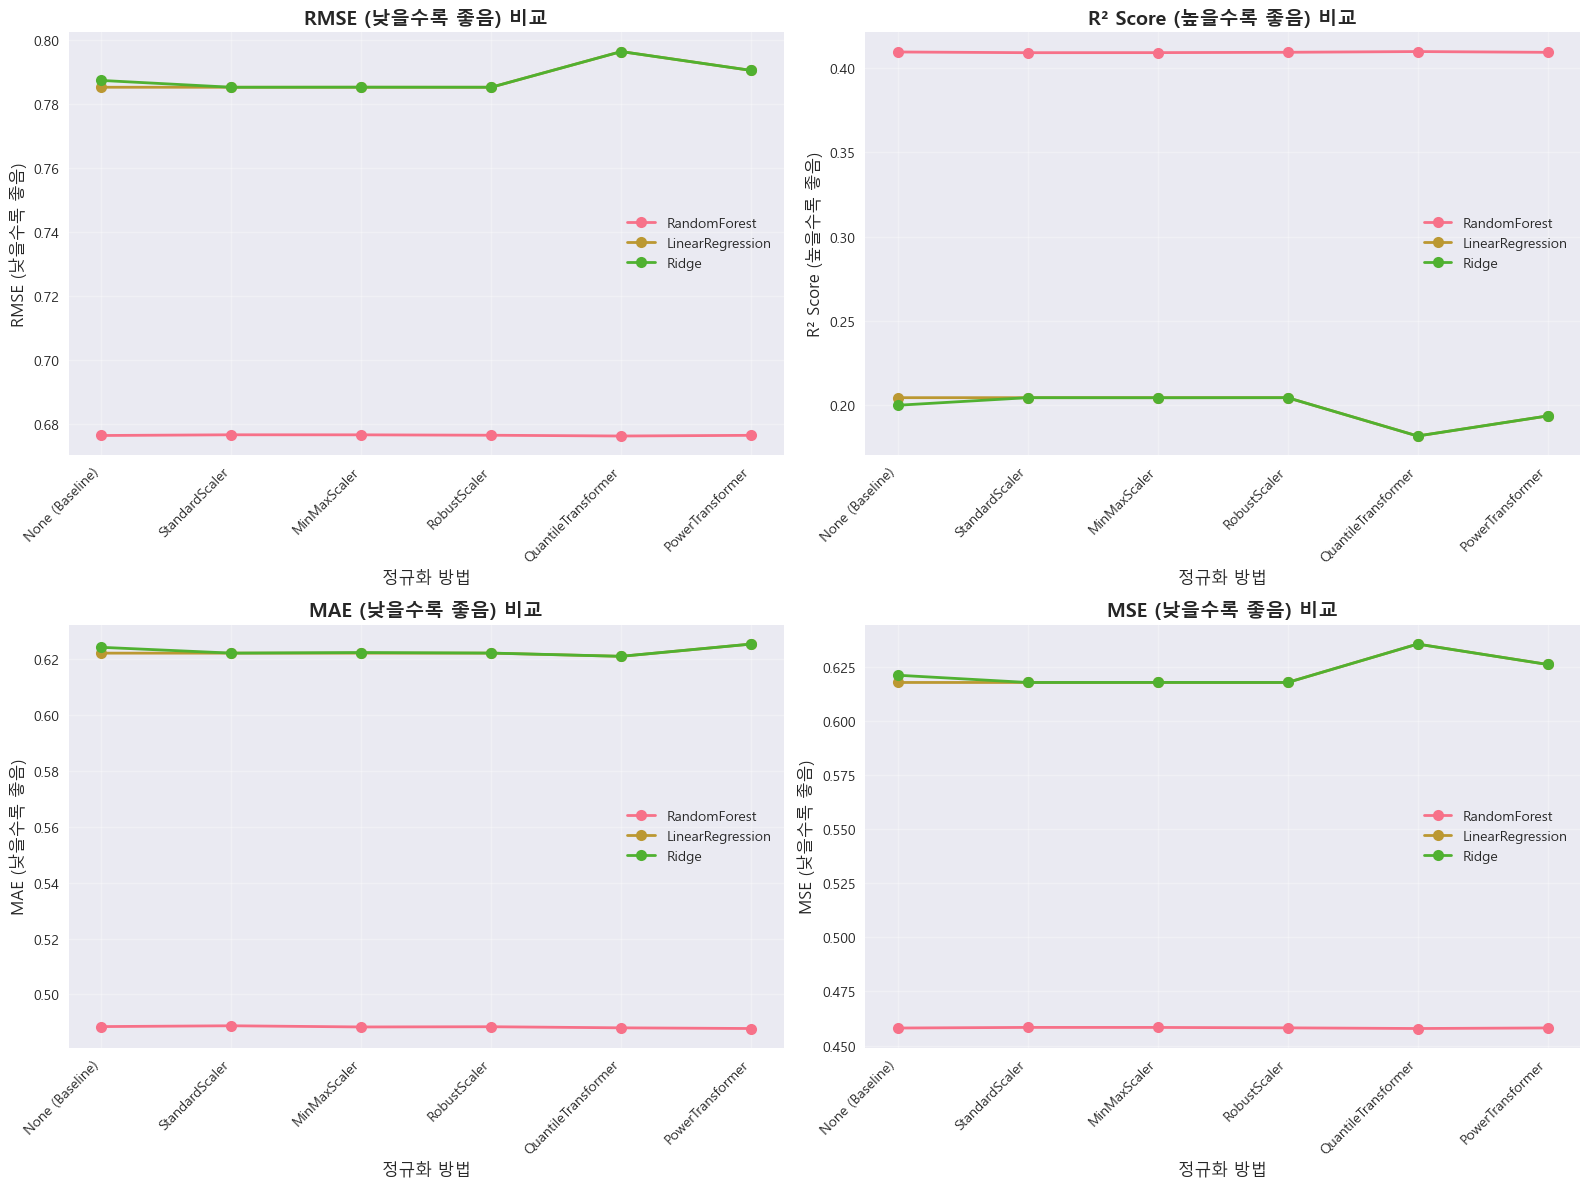

In [34]:
# 모델별로 정규화 방법 비교
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['rmse_mean', 'r2_mean', 'mae_mean', 'mse_mean']
metric_names = ['RMSE (낮을수록 좋음)', 'R² Score (높을수록 좋음)', 'MAE (낮을수록 좋음)', 'MSE (낮을수록 좋음)']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 2, idx % 2]
    
    # 모델별로 그룹화
    for model_name in models.keys():
        model_results = results_df[results_df['model'] == model_name]
        ax.plot(model_results['normalization'], model_results[metric], 
               marker='o', label=model_name, linewidth=2, markersize=8)
    
    ax.set_xlabel('정규화 방법', fontsize=12)
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_title(f'{metric_name} 비교', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


=== 정규화 방법별 성능 비교 (RandomForest 기준) ===
      normalization     RMSE       R²      MAE  composite_score
   PowerTransformer 0.676587 0.409284 0.487849         1.312368
QuantileTransformer 0.676375 0.409744 0.488090         1.312339
    None (Baseline) 0.676534 0.409494 0.488536         1.311516
       RobustScaler 0.676614 0.409309 0.488481         1.311473
       MinMaxScaler 0.676743 0.409106 0.488402         1.311422
     StandardScaler 0.676755 0.409071 0.488825         1.310811


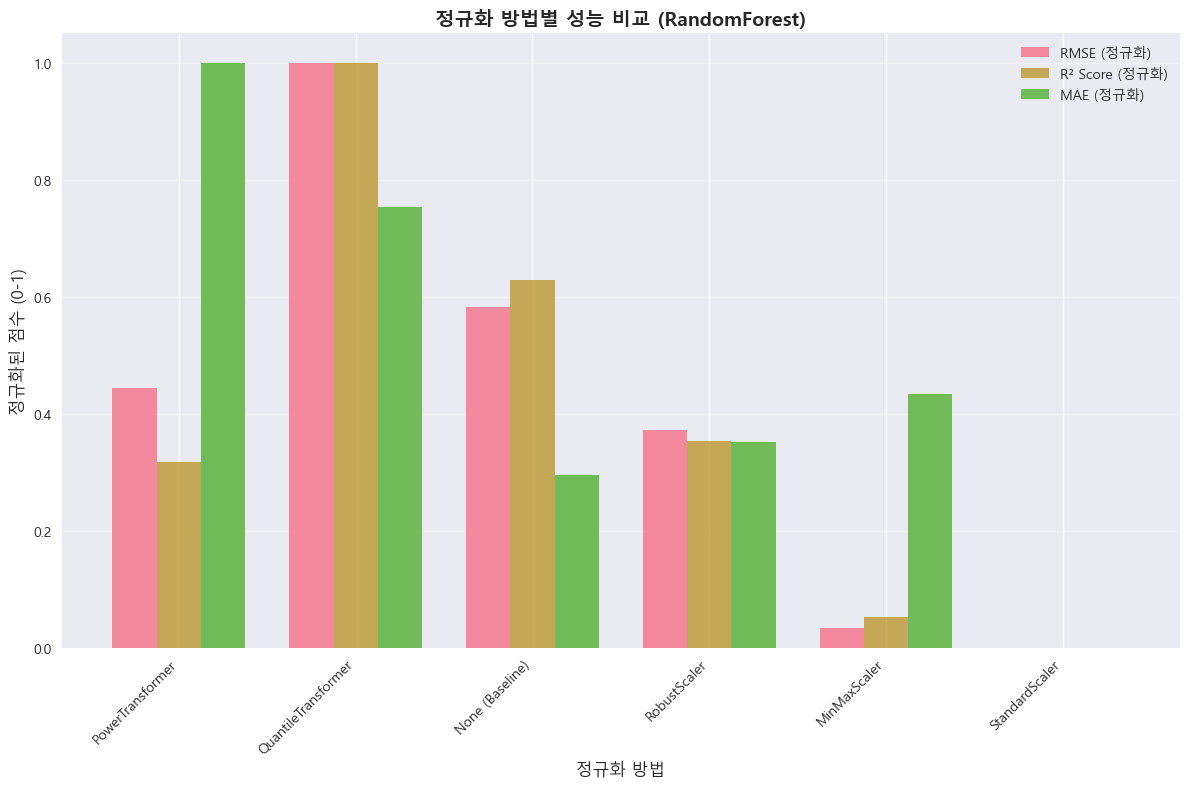

In [35]:
# 히트맵으로 성능 비교 (RandomForest 기준)
rf_results = results_df[results_df['model'] == 'RandomForest'].copy()

# 각 지표별로 정규화 방법 순위 매기기
metrics_for_ranking = ['rmse_mean', 'r2_mean', 'mae_mean']
normalization_list = rf_results['normalization'].values

# 정규화 방법별 점수 계산 (RMSE, MAE는 낮을수록 좋으므로 역수 사용)
comparison_matrix = []

for norm_method in normalization_list:
    row_data = rf_results[rf_results['normalization'] == norm_method].iloc[0]
    # RMSE와 MAE는 낮을수록 좋으므로, R²는 높을수록 좋음
    # 점수화: RMSE와 MAE는 역수, R²는 그대로
    score = (1 / (row_data['rmse_mean'] + 1e-10) + 
             row_data['r2_mean'] + 
             1 / (row_data['mae_mean'] + 1e-10)) / 3
    comparison_matrix.append({
        'normalization': norm_method,
        'RMSE': row_data['rmse_mean'],
        'R²': row_data['r2_mean'],
        'MAE': row_data['mae_mean'],
        'composite_score': score
    })

comparison_df = pd.DataFrame(comparison_matrix).sort_values('composite_score', ascending=False)

print("=== 정규화 방법별 성능 비교 (RandomForest 기준) ===")
print(comparison_df.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(12, 8))
x_pos = np.arange(len(comparison_df))
width = 0.25

# 정규화된 값으로 시각화 (각 지표를 0-1 범위로 정규화)
rmse_norm = 1 - (comparison_df['RMSE'] - comparison_df['RMSE'].min()) / (comparison_df['RMSE'].max() - comparison_df['RMSE'].min() + 1e-10)
r2_norm = (comparison_df['R²'] - comparison_df['R²'].min()) / (comparison_df['R²'].max() - comparison_df['R²'].min() + 1e-10)
mae_norm = 1 - (comparison_df['MAE'] - comparison_df['MAE'].min()) / (comparison_df['MAE'].max() - comparison_df['MAE'].min() + 1e-10)

ax.bar(x_pos - width, rmse_norm, width, label='RMSE (정규화)', alpha=0.8)
ax.bar(x_pos, r2_norm, width, label='R² Score (정규화)', alpha=0.8)
ax.bar(x_pos + width, mae_norm, width, label='MAE (정규화)', alpha=0.8)

ax.set_xlabel('정규화 방법', fontsize=12)
ax.set_ylabel('정규화된 점수 (0-1)', fontsize=12)
ax.set_title('정규화 방법별 성능 비교 (RandomForest)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df['normalization'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 4. 최적 정규화 방법 선정


In [36]:
# RandomForest 모델 기준으로 최적 정규화 방법 선정
rf_results_sorted = rf_results.sort_values('rmse_mean')

print("=" * 100)
print("=== 최적 정규화 방법 선정 (RandomForest 기준) ===")
print("=" * 100)

best_norm_method = rf_results_sorted.iloc[0]['normalization']
best_result = rf_results_sorted.iloc[0]

print(f"\n최적 정규화 방법: {best_norm_method}")
print(f"\n성능 지표:")
print(f"  RMSE: {best_result['rmse_mean']:.4f} (+/- {best_result['rmse_std']*2:.4f})")
print(f"  R²:   {best_result['r2_mean']:.4f} (+/- {best_result['r2_std']*2:.4f})")
print(f"  MAE:  {best_result['mae_mean']:.4f} (+/- {best_result['mae_std']*2:.4f})")
print(f"  MSE:  {best_result['mse_mean']:.4f} (+/- {best_result['mse_std']*2:.4f})")

print(f"\n{'='*100}")
print("전체 정규화 방법 순위 (RMSE 기준, 낮을수록 좋음)")
print(f"{'='*100}")
for idx, row in rf_results_sorted.iterrows():
    rank = list(rf_results_sorted.index).index(idx) + 1
    marker = "★" if rank == 1 else "  "
    print(f"{marker} {rank}. {row['normalization']:30s} - RMSE: {row['rmse_mean']:.4f}, R²: {row['r2_mean']:.4f}")

# 최적 정규화 방법의 데이터 저장
best_scaler = normalization_methods[best_norm_method]
if best_scaler is None:
    X_final_normalized = X_features.copy()
    scaler_final = None
else:
    scaler_final = best_scaler
    X_final_normalized = pd.DataFrame(
        scaler_final.fit_transform(X_features),
        columns=X_features.columns,
        index=X_features.index
    )

print(f"\n{'='*100}")
print(f"최종 선택된 정규화 방법: {best_norm_method}")
print(f"{'='*100}")
print(f"정규화된 피처 데이터 형태: {X_final_normalized.shape}")
print(f"\n정규화된 데이터 샘플:")
print(X_final_normalized.head())


=== 최적 정규화 방법 선정 (RandomForest 기준) ===

최적 정규화 방법: QuantileTransformer

성능 지표:
  RMSE: 0.6764 (+/- 0.0410)
  R²:   0.4097 (+/- 0.0371)
  MAE:  0.4881 (+/- 0.0208)
  MSE:  0.4579 (+/- 0.0554)

전체 정규화 방법 순위 (RMSE 기준, 낮을수록 좋음)
★ 1. QuantileTransformer            - RMSE: 0.6764, R²: 0.4097
   2. None (Baseline)                - RMSE: 0.6765, R²: 0.4095
   3. PowerTransformer               - RMSE: 0.6766, R²: 0.4093
   4. RobustScaler                   - RMSE: 0.6766, R²: 0.4093
   5. MinMaxScaler                   - RMSE: 0.6767, R²: 0.4091
   6. StandardScaler                 - RMSE: 0.6768, R²: 0.4091

최종 선택된 정규화 방법: QuantileTransformer
정규화된 피처 데이터 형태: (3292, 4)

정규화된 데이터 샘플:
    alcohol  total sulfur dioxide  chlorides   density
0 -1.968165              0.692715   0.282216  2.877846
1 -0.661162             -0.058999   0.681594  0.086674
2 -0.191865             -0.995858   0.786745  0.349483
3 -0.346817              1.012474   1.597698  0.530745
4 -0.346817              1.012474   1.5976

In [37]:
# 최종 정규화된 데이터프레임 생성
df_final_normalized = pd.concat([X_final_normalized, y_target], axis=1)

print("=" * 100)
print("=== 최종 정규화 완료 ===")
print("=" * 100)
print(f"정규화 방법: {best_norm_method}")
print(f"데이터 크기: {df_final_normalized.shape}")
print(f"피처 목록: {list(X_final_normalized.columns)}")
print(f"\n최종 데이터 샘플:")
print(df_final_normalized.head())

# 정규화 전후 비교
print(f"\n{'='*100}")
print("정규화 전후 비교")
print(f"{'='*100}")
print("\n정규화 전 통계:")
print(X_features.describe())
print("\n정규화 후 통계:")
print(X_final_normalized.describe())


=== 최종 정규화 완료 ===
정규화 방법: QuantileTransformer
데이터 크기: (3292, 5)
피처 목록: ['alcohol', 'total sulfur dioxide', 'chlorides', 'density']

최종 데이터 샘플:
    alcohol  total sulfur dioxide  chlorides   density  quality
0 -1.968165              0.692715   0.282216  2.877846        6
1 -0.661162             -0.058999   0.681594  0.086674        6
2 -0.191865             -0.995858   0.786745  0.349483        6
3 -0.346817              1.012474   1.597698  0.530745        6
4 -0.346817              1.012474   1.597698  0.530745        6

정규화 전후 비교

정규화 전 통계:
           alcohol  total sulfur dioxide    chlorides      density
count  3292.000000           3292.000000  3292.000000  3292.000000
mean     10.535358            139.057260     0.042039     0.994010
std       1.199917             42.389605     0.009989     0.002863
min       8.400000             19.000000     0.015000     0.987130
25%       9.500000            108.000000     0.035000     0.991727
50%      10.400000            134.500000     0.04

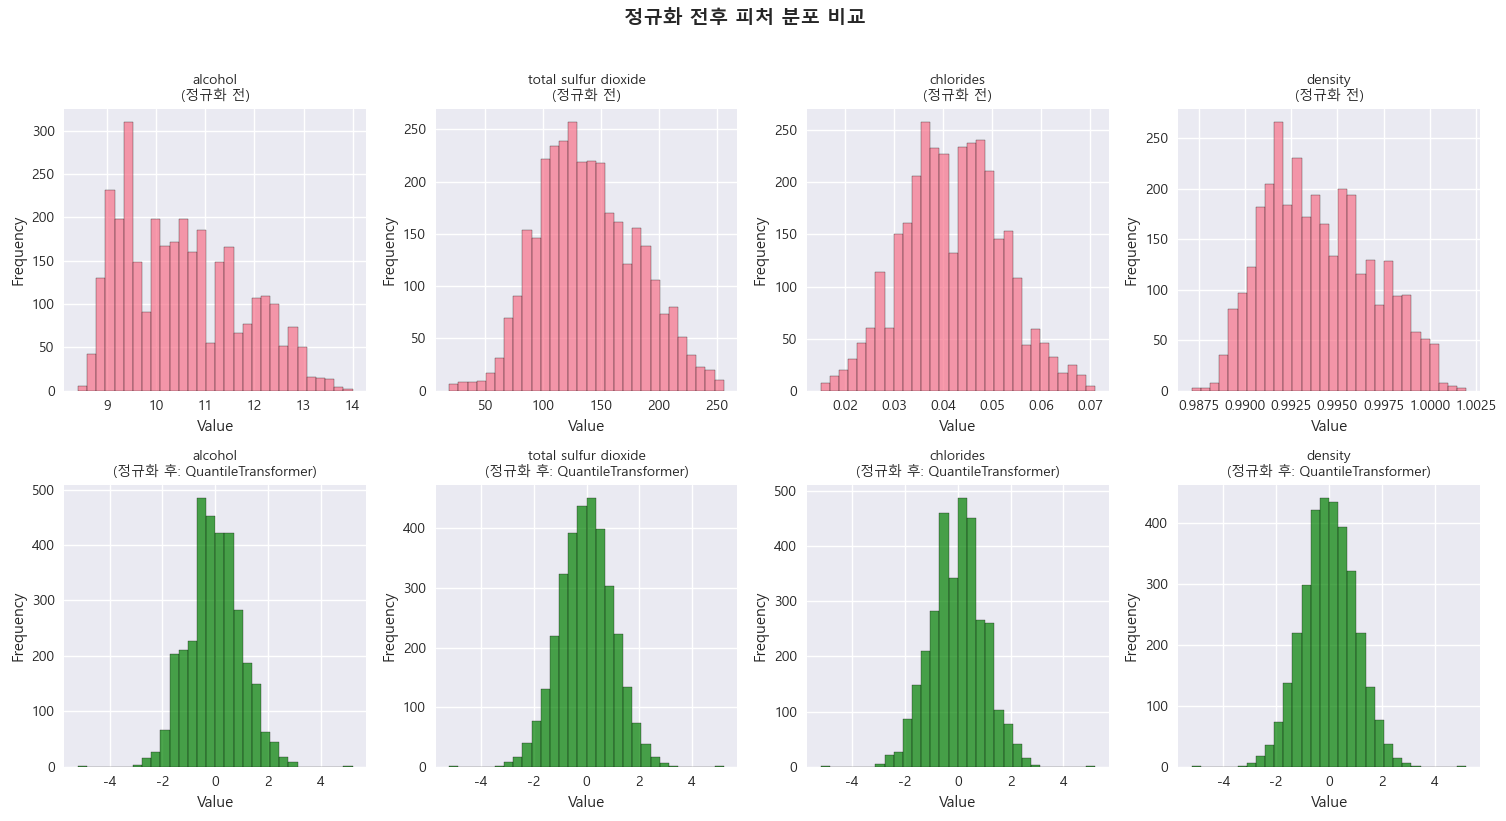

In [38]:
# 정규화 전후 분포 비교 시각화
fig, axes = plt.subplots(2, len(X_final_normalized.columns), figsize=(15, 8))

for idx, col in enumerate(X_final_normalized.columns):
    # 정규화 전
    axes[0, idx].hist(X_features[col], bins=30, alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(f'{col}\n(정규화 전)', fontsize=10)
    axes[0, idx].set_xlabel('Value')
    axes[0, idx].set_ylabel('Frequency')
    
    # 정규화 후
    axes[1, idx].hist(X_final_normalized[col], bins=30, alpha=0.7, edgecolor='black', color='green')
    axes[1, idx].set_title(f'{col}\n(정규화 후: {best_norm_method})', fontsize=10)
    axes[1, idx].set_xlabel('Value')
    axes[1, idx].set_ylabel('Frequency')

plt.suptitle('정규화 전후 피처 분포 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. MLflow를 활용한 모델 비교 및 하이퍼파라미터 튜닝


### 1. 데이터 준비 및 MLflow 설정


In [39]:
# Train/Test 분리 및 MLflow 설정
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

# XGBoost는 선택사항 (설치되어 있는 경우에만 사용)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost가 설치되지 않았습니다. XGBoost 모델은 제외됩니다.")

# MLflow 실험 설정
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Wine_Quality_Prediction_Optimization")

# 전처리 완료된 데이터 사용
X = X_final_normalized.copy()
y = y_target.copy()

# Train/Test 분리 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print("=" * 100)
print("=== 데이터 분리 완료 ===")
print("=" * 100)
print(f"전체 데이터: {X.shape[0]}개")
print(f"학습 데이터: {X_train.shape[0]}개 ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"테스트 데이터: {X_test.shape[0]}개 ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"피처 개수: {X_train.shape[1]}개")
print(f"피처 목록: {list(X.columns)}")
print(f"\n정규화 방법: {best_norm_method}")
print(f"MLflow 실험 이름: Wine_Quality_Prediction_Optimization")
print(f"MLflow Tracking URI: ./mlruns")


2025/11/24 22:47:55 INFO mlflow.tracking.fluent: Experiment with name 'Wine_Quality_Prediction_Optimization' does not exist. Creating a new experiment.


XGBoost가 설치되지 않았습니다. XGBoost 모델은 제외됩니다.
=== 데이터 분리 완료 ===
전체 데이터: 3292개
학습 데이터: 2633개 (80.0%)
테스트 데이터: 659개 (20.0%)
피처 개수: 4개
피처 목록: ['alcohol', 'total sulfur dioxide', 'chlorides', 'density']

정규화 방법: QuantileTransformer
MLflow 실험 이름: Wine_Quality_Prediction_Optimization
MLflow Tracking URI: ./mlruns


### 2. 모델 및 하이퍼파라미터 그리드 정의


In [40]:
# 다양한 모델과 하이퍼파라미터 그리드 정의
models_config = {
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'param_grid': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 8, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'param_grid': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }
    },
    'ElasticNet': {
        'model': ElasticNet(random_state=42, max_iter=1000),
        'param_grid': {
            'alpha': [0.1, 0.5, 1.0, 2.0],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    },
    'Ridge': {
        'model': Ridge(random_state=42),
        'param_grid': {
            'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
        }
    },
    'SVR': {
        'model': SVR(),
        'param_grid': {
            'C': [0.1, 1.0, 10.0],
            'gamma': ['scale', 'auto', 0.001, 0.01],
            'epsilon': [0.01, 0.1, 0.2]
        }
    }
}

# XGBoost 추가 (사용 가능한 경우)
if XGBOOST_AVAILABLE:
    models_config['XGBoost'] = {
        'model': xgb.XGBRegressor(random_state=42, n_jobs=-1),
        'param_grid': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }
    }

print("=" * 100)
print("=== 모델 및 하이퍼파라미터 설정 ===")
print("=" * 100)
for model_name, config in models_config.items():
    param_combinations = np.prod([len(v) if isinstance(v, list) else 1 for v in config['param_grid'].values()])
    print(f"\n{model_name}:")
    print(f"  파라미터 조합 수: {param_combinations}개")
    print(f"  파라미터 그리드: {config['param_grid']}")

total_combinations = sum([np.prod([len(v) if isinstance(v, list) else 1 for v in config['param_grid'].values()]) 
                          for config in models_config.values()])
print(f"\n총 파라미터 조합 수: {total_combinations}개")
print(f"10-Fold 교차검증 사용 시 총 학습 횟수: {total_combinations * 10}회")
print(f"\n⚠️ 주의: 실행 시간이 오래 걸릴 수 있습니다 (수십 분~수시간)")


=== 모델 및 하이퍼파라미터 설정 ===

RandomForest:
  파라미터 조합 수: 108개
  파라미터 그리드: {'n_estimators': [100, 200, 300], 'max_depth': [5, 8, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}

GradientBoosting:
  파라미터 조합 수: 36개
  파라미터 그리드: {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7], 'min_samples_split': [2, 5]}

ElasticNet:
  파라미터 조합 수: 20개
  파라미터 그리드: {'alpha': [0.1, 0.5, 1.0, 2.0], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}

Ridge:
  파라미터 조합 수: 5개
  파라미터 그리드: {'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]}

SVR:
  파라미터 조합 수: 36개
  파라미터 그리드: {'C': [0.1, 1.0, 10.0], 'gamma': ['scale', 'auto', 0.001, 0.01], 'epsilon': [0.01, 0.1, 0.2]}

총 파라미터 조합 수: 205개
10-Fold 교차검증 사용 시 총 학습 횟수: 2050회

⚠️ 주의: 실행 시간이 오래 걸릴 수 있습니다 (수십 분~수시간)


### 3. 하이퍼파라미터 튜닝 및 MLflow 로깅


In [41]:
# GridSearchCV를 사용한 하이퍼파라미터 튜닝 및 MLflow 로깅
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# 결과 저장용
all_results = []

print("=" * 100)
print("=== MLflow 실험 시작: 하이퍼파라미터 튜닝 ===")
print("=" * 100)
print(f"교차검증: 10-Fold")
print(f"총 모델 수: {len(models_config)}개")
print(f"각 모델별로 GridSearchCV 실행 중...\n")

for idx, (model_name, config) in enumerate(models_config.items(), 1):
    print(f"\n{'='*100}")
    print(f"[{idx}/{len(models_config)}] 모델: {model_name}")
    print(f"{'='*100}")
    
    # GridSearchCV
    grid_search = GridSearchCV(
        config['model'],
        config['param_grid'],
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    
    # 하이퍼파라미터 튜닝
    print(f"GridSearchCV 실행 중...")
    grid_search.fit(X_train, y_train)
    
    # 최적 모델
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_cv_score = -grid_search.best_score_
    
    # 예측
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    # 성능 지표 계산
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # MLflow에 로깅
    with mlflow.start_run(run_name=f"{model_name}_optimized"):
        # 파라미터 로깅
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("normalization_method", best_norm_method)
        mlflow.log_param("n_features", X.shape[1])
        mlflow.log_param("features", str(list(X.columns)))
        
        for param_name, param_value in best_params.items():
            mlflow.log_param(param_name, param_value)
        
        # 메트릭 로깅
        mlflow.log_metric("train_mse", train_mse)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("train_mae", train_mae)
        mlflow.log_metric("test_mse", test_mse)
        mlflow.log_metric("test_rmse", test_rmse)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("test_mae", test_mae)
        mlflow.log_metric("cv_score_mean", best_cv_score)
        mlflow.log_metric("cv_score_std", grid_search.cv_results_['std_test_score'][grid_search.best_index_])
        
        # 모델 저장
        mlflow.sklearn.log_model(best_model, "model")
        
        # 피처 중요도 (가능한 경우)
        if hasattr(best_model, 'feature_importances_'):
            feature_importance = dict(zip(X.columns, best_model.feature_importances_))
            for feat, imp in feature_importance.items():
                mlflow.log_metric(f"importance_{feat}", imp)
    
    # 결과 저장
    all_results.append({
        'model': model_name,
        'best_params': best_params,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'cv_score': best_cv_score,
        'best_model': best_model
    })
    
    # 결과 출력
    print(f"\n✓ 완료!")
    print(f"최적 파라미터: {best_params}")
    print(f"교차검증 점수 (MSE): {best_cv_score:.4f}")
    print(f"\n학습 성능:")
    print(f"  RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}, MAE: {train_mae:.4f}")
    print(f"\n테스트 성능:")
    print(f"  RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}, MAE: {test_mae:.4f}")

print(f"\n{'='*100}")
print("✓ 모든 실험 완료!")
print(f"{'='*100}")


=== MLflow 실험 시작: 하이퍼파라미터 튜닝 ===
교차검증: 10-Fold
총 모델 수: 5개
각 모델별로 GridSearchCV 실행 중...


[1/5] 모델: RandomForest
GridSearchCV 실행 중...
Fitting 10 folds for each of 108 candidates, totalling 1080 fits


2025/11/24 22:50:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/24 22:50:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✓ 완료!
최적 파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
교차검증 점수 (MSE): 0.4860

학습 성능:
  RMSE: 0.2555, R²: 0.9149, MAE: 0.1813

테스트 성능:
  RMSE: 0.6722, R²: 0.4455, MAE: 0.4931

[2/5] 모델: GradientBoosting
GridSearchCV 실행 중...
Fitting 10 folds for each of 36 candidates, totalling 360 fits


2025/11/24 22:51:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/24 22:51:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✓ 완료!
최적 파라미터: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 100}
교차검증 점수 (MSE): 0.5336

학습 성능:
  RMSE: 0.3797, R²: 0.8122, MAE: 0.2824

테스트 성능:
  RMSE: 0.6910, R²: 0.4141, MAE: 0.5248

[3/5] 모델: ElasticNet
GridSearchCV 실행 중...
Fitting 10 folds for each of 20 candidates, totalling 200 fits


...


✓ 완료!
최적 파라미터: {'alpha': 0.1, 'l1_ratio': 0.1}
교차검증 점수 (MSE): 0.6428

학습 성능:
  RMSE: 0.8004, R²: 0.1653, MAE: 0.6241

테스트 성능:
  RMSE: 0.7894, R²: 0.2352, MAE: 0.6135

[4/5] 모델: Ridge
GridSearchCV 실행 중...
Fitting 10 folds for each of 5 candidates, totalling 50 fits


2025/11/24 22:51:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✓ 완료!
최적 파라미터: {'alpha': 10.0}
교차검증 점수 (MSE): 0.6404

학습 성능:
  RMSE: 0.7986, R²: 0.1689, MAE: 0.6222

테스트 성능:
  RMSE: 0.7839, R²: 0.2459, MAE: 0.6071

[5/5] 모델: SVR
GridSearchCV 실행 중...
Fitting 10 folds for each of 36 candidates, totalling 360 fits


2025/11/24 22:51:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/24 22:51:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✓ 완료!
최적 파라미터: {'C': 1.0, 'epsilon': 0.2, 'gamma': 'auto'}
교차검증 점수 (MSE): 0.5988

학습 성능:
  RMSE: 0.7504, R²: 0.2664, MAE: 0.5822

테스트 성능:
  RMSE: 0.7658, R²: 0.2802, MAE: 0.6023

✓ 모든 실험 완료!


In [42]:
# 결과 비교 및 최고 모델 선정
results_df = pd.DataFrame(all_results)

print("=" * 100)
print("=== 모든 모델 성능 비교 (테스트 세트 기준) ===")
print("=" * 100)
comparison_cols = ['model', 'test_rmse', 'test_r2', 'test_mae', 'cv_score']
print(results_df[comparison_cols].to_string(index=False))

# 최고 성능 모델 선정 (테스트 RMSE 기준)
best_idx = results_df['test_rmse'].idxmin()
best_result = results_df.iloc[best_idx]

print(f"\n{'='*100}")
print("=== 최고 성능 모델 ===")
print(f"{'='*100}")
print(f"모델: {best_result['model']}")
print(f"최적 파라미터: {best_result['best_params']}")
print(f"\n성능 지표:")
print(f"  테스트 RMSE: {best_result['test_rmse']:.4f}")
print(f"  테스트 R²:   {best_result['test_r2']:.4f}")
print(f"  테스트 MAE:  {best_result['test_mae']:.4f}")
print(f"  교차검증 점수 (MSE): {best_result['cv_score']:.4f}")

# 최고 모델 저장
best_model_final = best_result['best_model']


=== 모든 모델 성능 비교 (테스트 세트 기준) ===
           model  test_rmse  test_r2  test_mae  cv_score
    RandomForest   0.672208 0.445451  0.493096  0.486033
GradientBoosting   0.690950 0.414097  0.524782  0.533556
      ElasticNet   0.789421 0.235197  0.613549  0.642810
           Ridge   0.783903 0.245852  0.607055  0.640377
             SVR   0.765834 0.280217  0.602350  0.598802

=== 최고 성능 모델 ===
모델: RandomForest
최적 파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

성능 지표:
  테스트 RMSE: 0.6722
  테스트 R²:   0.4455
  테스트 MAE:  0.4931
  교차검증 점수 (MSE): 0.4860


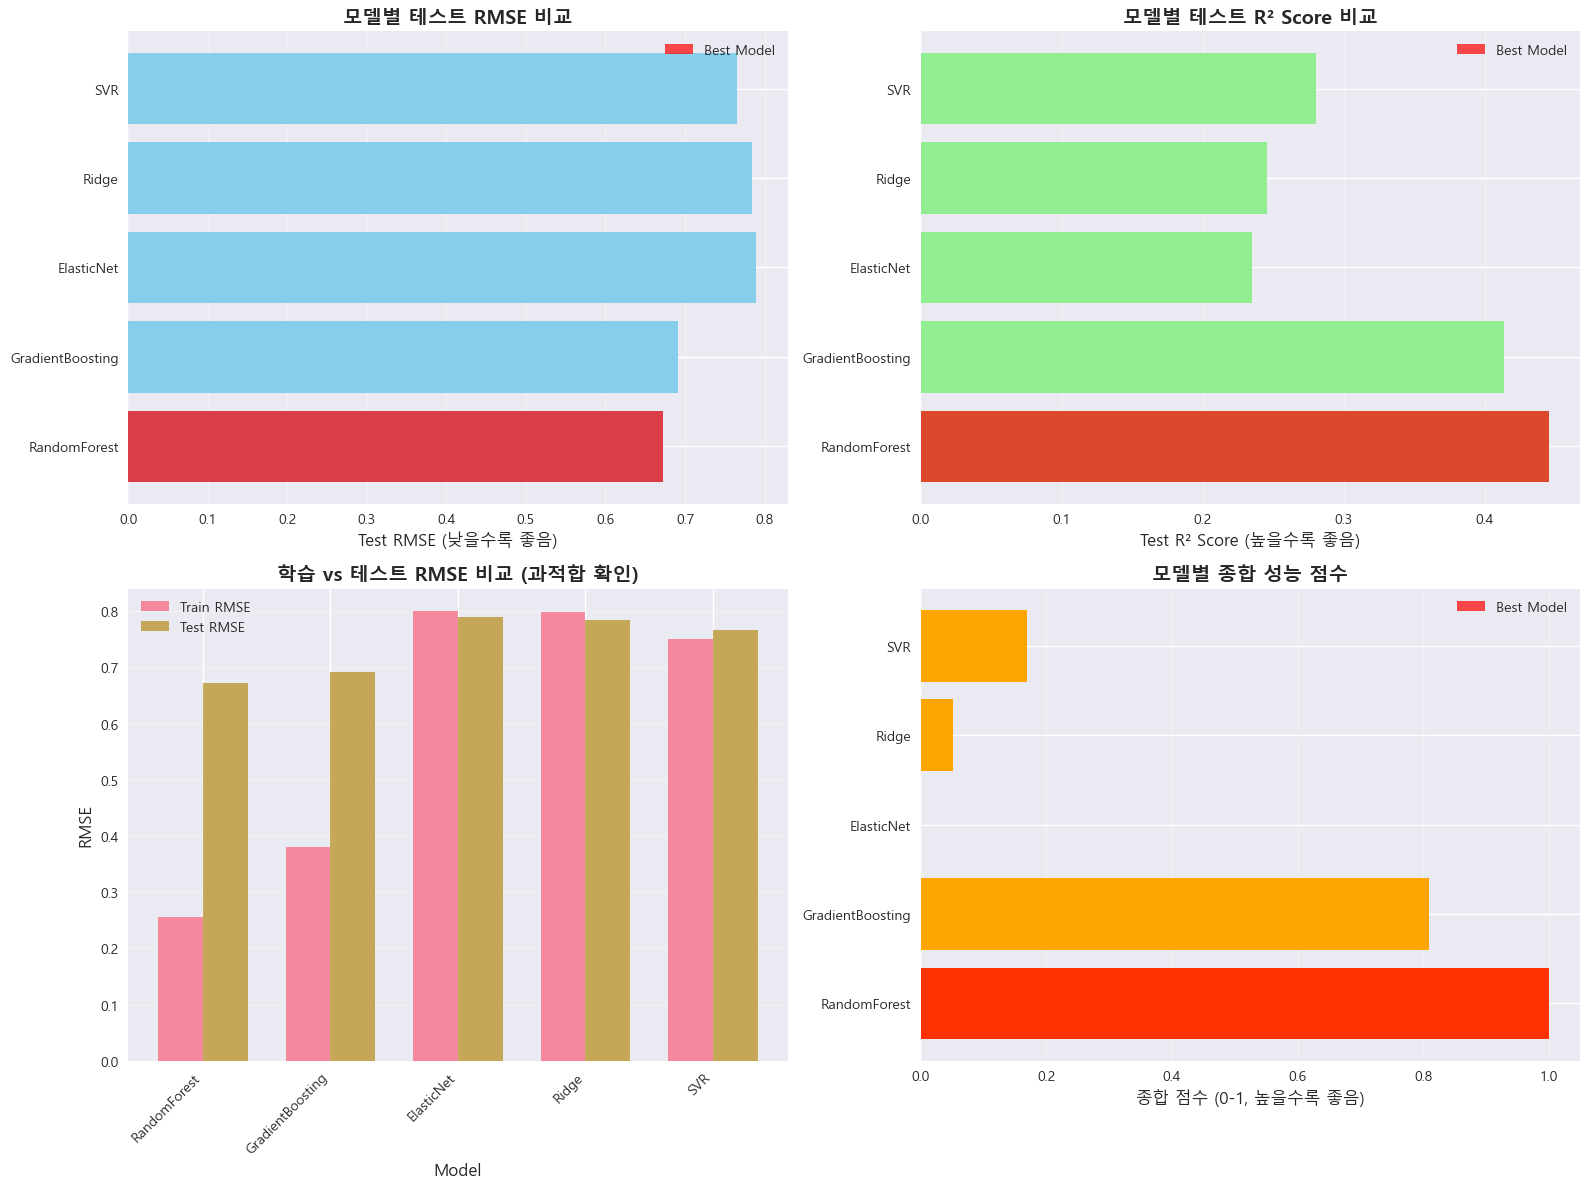

In [43]:
# 성능 비교 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 테스트 RMSE 비교
axes[0, 0].barh(results_df['model'], results_df['test_rmse'], color='skyblue')
axes[0, 0].set_xlabel('Test RMSE (낮을수록 좋음)', fontsize=12)
axes[0, 0].set_title('모델별 테스트 RMSE 비교', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
best_model_name = best_result['model']
best_rmse = best_result['test_rmse']
axes[0, 0].barh(best_model_name, best_rmse, color='red', alpha=0.7, label='Best Model')
axes[0, 0].legend()

# 2. 테스트 R² 비교
axes[0, 1].barh(results_df['model'], results_df['test_r2'], color='lightgreen')
axes[0, 1].set_xlabel('Test R² Score (높을수록 좋음)', fontsize=12)
axes[0, 1].set_title('모델별 테스트 R² Score 비교', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
best_r2 = best_result['test_r2']
axes[0, 1].barh(best_model_name, best_r2, color='red', alpha=0.7, label='Best Model')
axes[0, 1].legend()

# 3. 학습 vs 테스트 RMSE 비교 (과적합 확인)
x_pos = np.arange(len(results_df))
width = 0.35
axes[1, 0].bar(x_pos - width/2, results_df['train_rmse'], width, label='Train RMSE', alpha=0.8)
axes[1, 0].bar(x_pos + width/2, results_df['test_rmse'], width, label='Test RMSE', alpha=0.8)
axes[1, 0].set_xlabel('Model', fontsize=12)
axes[1, 0].set_ylabel('RMSE', fontsize=12)
axes[1, 0].set_title('학습 vs 테스트 RMSE 비교 (과적합 확인)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(results_df['model'], rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. 종합 성능 비교 (정규화된 점수)
rmse_norm = 1 - (results_df['test_rmse'] - results_df['test_rmse'].min()) / (results_df['test_rmse'].max() - results_df['test_rmse'].min() + 1e-10)
r2_norm = (results_df['test_r2'] - results_df['test_r2'].min()) / (results_df['test_r2'].max() - results_df['test_r2'].min() + 1e-10)
mae_norm = 1 - (results_df['test_mae'] - results_df['test_mae'].min()) / (results_df['test_mae'].max() - results_df['test_mae'].min() + 1e-10)
composite_score = (rmse_norm + r2_norm + mae_norm) / 3

axes[1, 1].barh(results_df['model'], composite_score, color='orange')
axes[1, 1].set_xlabel('종합 점수 (0-1, 높을수록 좋음)', fontsize=12)
axes[1, 1].set_title('모델별 종합 성능 점수', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')
best_score = composite_score.iloc[best_idx]
axes[1, 1].barh(best_model_name, best_score, color='red', alpha=0.7, label='Best Model')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


### 5. 최종 모델 상세 분석


In [45]:
# 최종 모델로 예측 및 상세 분석
y_test_pred_best = best_model_final.predict(X_test)

print("=" * 100)
print("=== 최종 모델 상세 분석 ===")
print("=" * 100)

# 예측값과 실제값 비교 (인덱스를 y_test와 일치시킴)
comparison_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred_best,
    'error': y_test.values - y_test_pred_best,
    'abs_error': np.abs(y_test.values - y_test_pred_best)
}, index=y_test.index)  # 인덱스를 y_test와 일치시킴

print("\n예측 결과 샘플 (상위 20개):")
print(comparison_df.head(20))

print(f"\n오차 통계:")
print(f"  평균 절대 오차: {comparison_df['abs_error'].mean():.4f}")
print(f"  오차 표준편차: {comparison_df['error'].std():.4f}")
print(f"  최대 오차: {comparison_df['abs_error'].max():.4f}")
print(f"  최소 오차: {comparison_df['abs_error'].min():.4f}")
print(f"  중앙값 절대 오차: {comparison_df['abs_error'].median():.4f}")

# Quality 값별 예측 정확도 분석
quality_accuracy = []
for q in sorted(y_test.unique()):
    mask = y_test == q
    if mask.sum() > 0:
        # comparison_df의 인덱스가 y_test와 일치하므로 mask를 그대로 사용 가능
        mae = comparison_df.loc[mask, 'abs_error'].mean()
        quality_accuracy.append({'quality': q, 'count': mask.sum(), 'mae': mae})

quality_acc_df = pd.DataFrame(quality_accuracy)
print(f"\nQuality 값별 예측 정확도:")
print(quality_acc_df.to_string(index=False))

=== 최종 모델 상세 분석 ===

예측 결과 샘플 (상위 20개):
      actual  predicted     error  abs_error
3775       6   6.353333 -0.353333   0.353333
3845       5   6.016667 -1.016667   1.016667
3850       6   6.433333 -0.433333   0.433333
2453       6   6.353333 -0.353333   0.353333
2979       7   6.586667  0.413333   0.413333
1712       6   5.423333  0.576667   0.576667
1857       5   5.103333 -0.103333   0.103333
304        6   5.310000  0.690000   0.690000
258        6   6.796667 -0.796667   0.796667
3874       5   5.426667 -0.426667   0.426667
3809       6   5.900000  0.100000   0.100000
1170       6   5.590000  0.410000   0.410000
2533       5   6.073333 -1.073333   1.073333
1055       5   5.610000 -0.610000   0.610000
1134       5   5.936667 -0.936667   0.936667
3802       5   5.446667 -0.446667   0.446667
413        5   5.836667 -0.836667   0.836667
1392       6   6.873333 -0.873333   0.873333
3476       8   7.693333  0.306667   0.306667
2988       7   6.533333  0.466667   0.466667

오차 통계:
  평균 절대

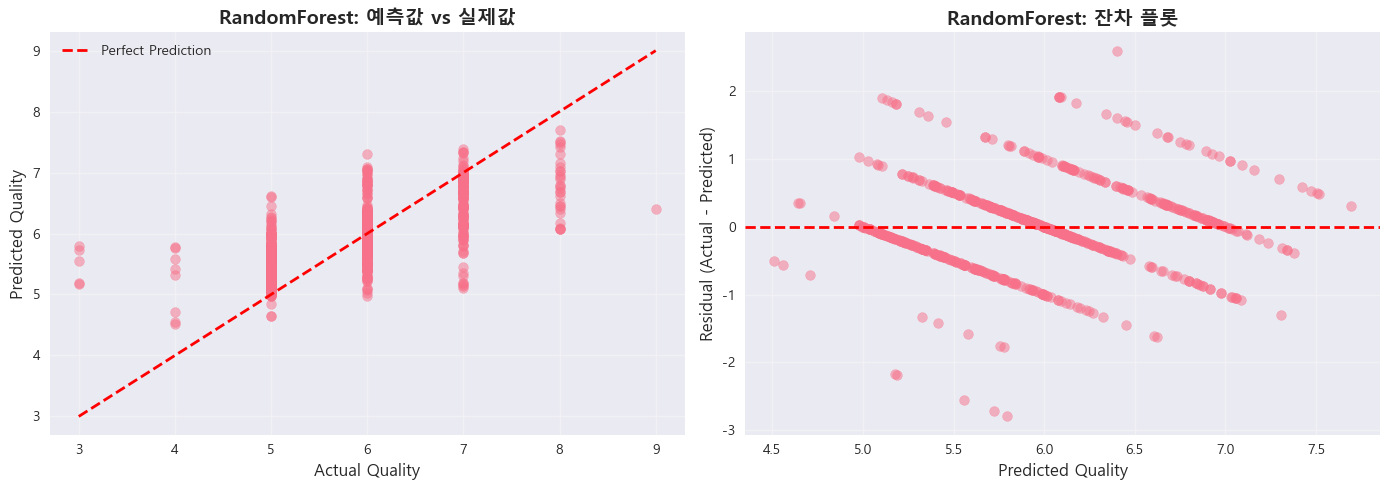

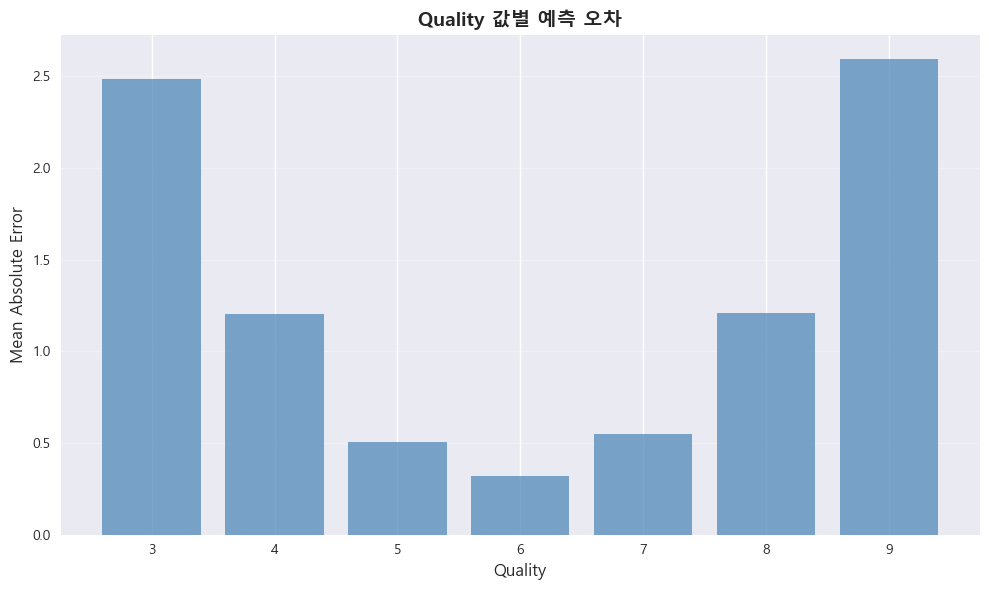

In [46]:
# 예측값 vs 실제값 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 산점도
axes[0].scatter(y_test, y_test_pred_best, alpha=0.5, s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Quality', fontsize=12)
axes[0].set_ylabel('Predicted Quality', fontsize=12)
axes[0].set_title(f'{best_model_name}: 예측값 vs 실제값', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 잔차 플롯
axes[1].scatter(y_test_pred_best, comparison_df['error'], alpha=0.5, s=50)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Quality', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_title(f'{best_model_name}: 잔차 플롯', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quality 값별 예측 정확도 시각화
if len(quality_acc_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(quality_acc_df['quality'], quality_acc_df['mae'], color='steelblue', alpha=0.7)
    ax.set_xlabel('Quality', fontsize=12)
    ax.set_ylabel('Mean Absolute Error', fontsize=12)
    ax.set_title('Quality 값별 예측 오차', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


=== 최종 모델 피처 중요도 ===
             feature  importance
             alcohol    0.315991
             density    0.255233
total sulfur dioxide    0.246615
           chlorides    0.182161


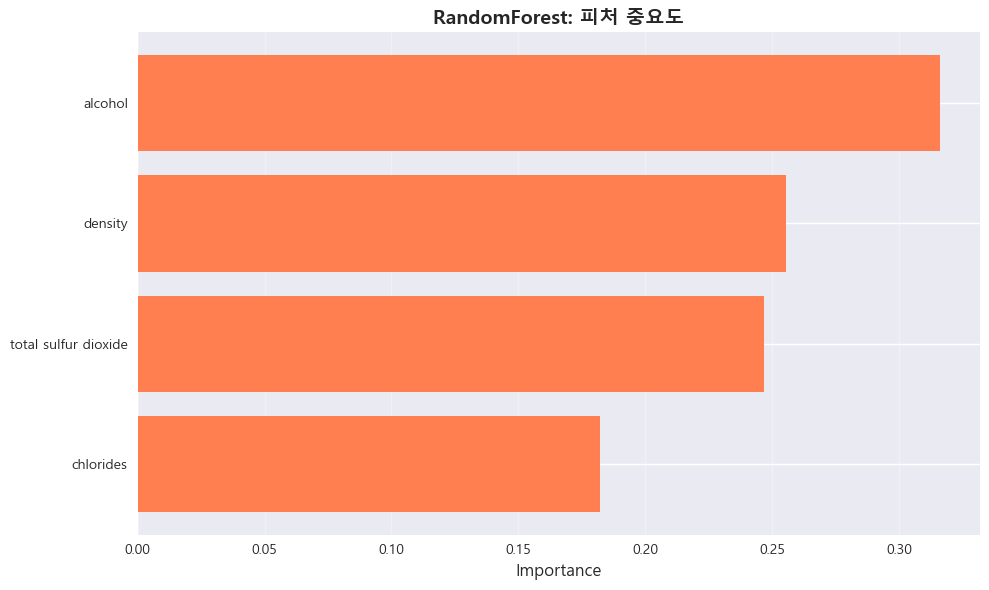


=== MLflow 실험 완료 ===
모든 실험 결과가 MLflow에 저장되었습니다.
MLflow UI에서 결과를 확인하려면 다음 명령어를 실행하세요:
  mlflow ui --backend-store-uri ./mlruns

최고 성능 모델: RandomForest
테스트 RMSE: 0.6722
테스트 R²: 0.4455


In [47]:
# 피처 중요도 시각화 (가능한 경우)
if hasattr(best_model_final, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model_final.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("=" * 100)
    print("=== 최종 모델 피처 중요도 ===")
    print("=" * 100)
    print(feature_importance.to_string(index=False))
    
    # 피처 중요도 시각화
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], feature_importance['importance'], color='coral')
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'{best_model_name}: 피처 중요도', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

print(f"\n{'='*100}")
print("=== MLflow 실험 완료 ===")
print(f"{'='*100}")
print(f"모든 실험 결과가 MLflow에 저장되었습니다.")
print(f"MLflow UI에서 결과를 확인하려면 다음 명령어를 실행하세요:")
print(f"  mlflow ui --backend-store-uri ./mlruns")
print(f"\n최고 성능 모델: {best_model_name}")
print(f"테스트 RMSE: {best_result['test_rmse']:.4f}")
print(f"테스트 R²: {best_result['test_r2']:.4f}")
print(f"{'='*100}")
